# **Домашнее задание 4 (base): древесные алгоритмы**

### Выполнил Мерочкин Илья

### **Постановка задачи:**

У вас есть данные о полетах, обладающие следущими характеристиками:
- Для **каждого** клиента известна краткая информация о самом человеке, о типе билета и о рейсе, а также оценки клиента различным аспектам полета.
- Для **некоторых** клиентов известна их удовлетворенность полетом (satisfied или neutral or dissatisfied).

По данным необходимо обучить модель, предсказывающую удовлетворенность клиентов полетом. Итоговые предсказания нужно сделать для клиентов, **для которых ответ неизвестен.**

### **Получение данных:**

Компания держит все данные в облаке Яндекса в Postgresql. Данные разбиты на смысловые таблицы. Чтобы получить данные, вам необходимо подключиться к базе данных и добыть оттуда данные.

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 0.7 бонусных баллов.

Оценка за ДЗ = min{ваш балл, 10}

Мягкий дедлайн: 29 января 23:59

**Продуктивной и интересной вам работы!**

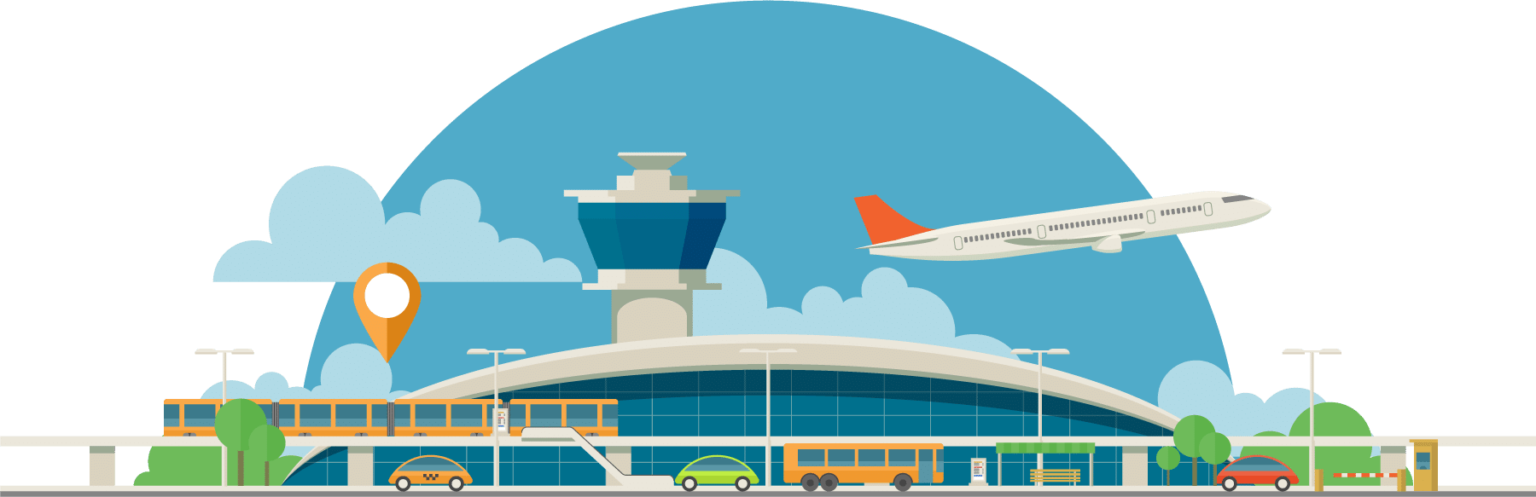

In [1]:
# установка всех библиотек, необходимых для выполнения ДЗ

!pip install catboost
# !pip install mlxtend --upgrade
!pip install optuna
!pip install lime
!pip install shap
#!pip install missingno
#!pip install psycopg2-binary
#!pip install xgboost
#!brew install cmake libomp
#!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=81bdae82db8f5fc39288cefc9554ea61b018345d4be02fb77c9b3e03c487211e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno

import psycopg2
import psycopg2.extras

from mlxtend.plotting import plot_decision_regions
from mlxtend.evaluate import bias_variance_decomp
from graphviz import Source
from sklearn.tree import export_graphviz
from IPython.display import SVG

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.calibration import CalibrationDisplay, calibration_curve, CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, mutual_info_classif
from sklearn.feature_selection import SequentialFeatureSelector, RFE, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator

from scipy.stats import randint, uniform

import shap
import lime
import lime.lime_tabular

import optuna

import pickle

np.random.seed(42)

# **Часть 1: Получение данных, обработка и EDA (2.75 балла)**

В этой части вам необходимо:
- Загрузить данные из БД и предобработать их (1.75 бала)
- Провести разведочный анализ данных (1. балл)

## **1. 1. Загрузка и предобработка данных (1.75 балла)**

In [3]:
!mkdir -p ~/.postgresql && \
wget "https://storage.yandexcloud.net/cloud-certs/CA.pem" \
    --output-document ~/.postgresql/root.crt && \
chmod 0600 ~/.postgresql/root.crt

--2026-03-18 21:29:45--  https://storage.yandexcloud.net/cloud-certs/CA.pem
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3579 (3.5K) [application/x-x509-ca-cert]
Saving to: ‘/root/.postgresql/root.crt’

/root/.postgresql/r 100%[===================>]   3.50K  --.-KB/s    in 0s      

2026-03-18 21:29:46 (1.43 GB/s) - ‘/root/.postgresql/root.crt’ saved [3579/3579]



### **Задание 1. Получение данных (0.5 балла)**

- Подключитесь к БД при помощи `psycopg2.connect()`
- Напишите SQL-запрос, объединяющий 3 нужные таблицы в одну
- Результат запроса поместите в `pd.DataFrame`. Индексом получившегося датафрейма сделайте столбец 'id'.

Список столбцов таблиц добудьте самостоятельно.


**Примечание:**
 Не забудьте закрыть соединение. Или открывайте соединение, используя менеджер контекста `with as`, который закроет его автоматически

##### **Параметры соединения:**
```
host=rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net
port=6432
sslmode=verify-full
dbname=db_flights
user=mlhs_student
password=mlhs_student
target_session_attrs=read-write```
```

##### **Схема БД**

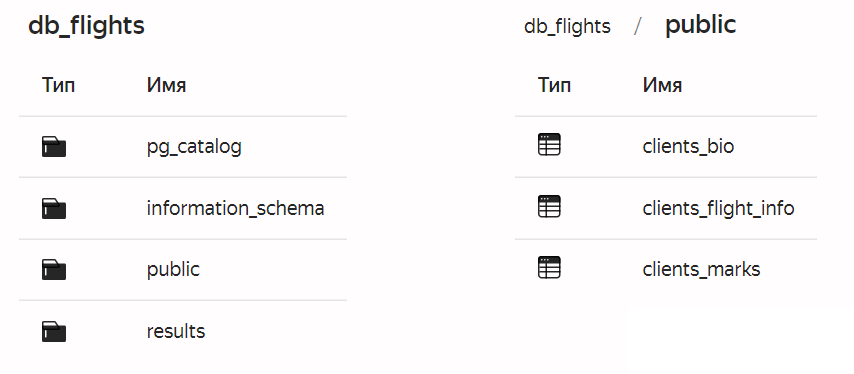



In [4]:
conn_params = {
    'host': 'rc1b-70q90cunwkzx49mj.mdb.yandexcloud.net',
    'port': 6432,
    'sslmode': 'verify-full',
    'dbname': 'db_flights',
    'user': 'mlhs_student',
    'password': 'mlhs_student',
    'target_session_attrs': 'read-write'
}

with psycopg2.connect(**conn_params) as conn:
    sql_query = """
    SELECT cb.id, cb.gender, cb.age,
    cfi."Customer Type", cfi."Type of Travel", cfi."class",
    cfi."Flight Distance", cfi."Departure Delay in Minutes", cfi."Arrival Delay in Minutes",
    cm."Inflight wifi service", cm."Departure/Arrival time convenient", cm."Ease of Online booking",
    cm."Gate location", cm."Food and drink", cm."Online boarding", cm."Seat comfort",
    cm."Inflight entertainment", cm."On-board service", cm."Leg room service", cm."Baggage handling",
    cm."Checkin service", cm."Inflight service", cm."cleanliness", cm."satisfaction"
    FROM db_flights.public.clients_bio as cb
    LEFT JOIN db_flights.public.clients_flight_info as cfi ON cb.id = cfi.id
    LEFT JOIN db_flights.public.clients_marks as cm ON cfi.id = cm.id
    """

    df = pd.read_sql(sql_query, conn)

df.set_index('id', inplace=True)
df.head()

/tmp/ipykernel_515/2159844221.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql_query, conn)


,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness,satisfaction
id,,,,,,,,,,,,,,,,,,,,,
7,Male,43.0,Loyal Customer,Business travel,Business,1963.0,0.0,0.0,3.0,3.0,...,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,satisfied
13,Male,24.0,disloyal Customer,Business travel,Eco,453.0,16.0,30.0,2.0,2.0,...,2.0,5.0,5.0,2.0,4.0,4.0,2.0,4.0,5.0,neutral or dissatisfied
18,Female,61.0,Loyal Customer,Personal Travel,Eco,821.0,0.0,0.0,2.0,5.0,...,1.0,5.0,5.0,5.0,2.0,5.0,5.0,5.0,1.0,neutral or dissatisfied
31,Male,35.0,disloyal Customer,Business travel,Business,212.0,0.0,0.0,2.0,2.0,...,2.0,2.0,2.0,4.0,5.0,5.0,5.0,4.0,2.0,neutral or dissatisfied
39,Female,46.0,Loyal Customer,Business travel,Business,67.0,0.0,0.0,3.0,3.0,...,5.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,5.0,satisfied


In [5]:
assert df.shape == (129_549, 23)

### **Задание 2 (0.25 балла)**

- Преобразуйте числовые столбцы в `float`. Проверьте, есть ли в датафрейме пропуски и выбросы (в том числе в категориальных признаках)</font>.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129549 entries, 7 to 129876
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   gender                             129549 non-null  object
 1   age                                129549 non-null  object
 2   Customer Type                      129549 non-null  object
 3   Type of Travel                     129549 non-null  object
 4   class                              129549 non-null  object
 5   Flight Distance                    129549 non-null  object
 6   Departure Delay in Minutes         129549 non-null  object
 7   Arrival Delay in Minutes           129549 non-null  object
 8   Inflight wifi service              129549 non-null  object
 9   Departure/Arrival time convenient  129549 non-null  object
 10  Ease of Online booking             129549 non-null  object
 11  Gate location                      129549 non-null  objec

In [8]:
numeric_columns = [
    'age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
    'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Inflight service', 'cleanliness'
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129549 entries, 7 to 129876
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   gender                             129549 non-null  object 
 1   age                                129234 non-null  float64
 2   Customer Type                      129549 non-null  object 
 3   Type of Travel                     129549 non-null  object 
 4   class                              129549 non-null  object 
 5   Flight Distance                    129455 non-null  float64
 6   Departure Delay in Minutes         129442 non-null  float64
 7   Arrival Delay in Minutes           129042 non-null  float64
 8   Inflight wifi service              129505 non-null  float64
 9   Departure/Arrival time convenient  129500 non-null  float64
 10  Ease of Online booking             129506 non-null  float64
 11  Gate location                      129512 no

In [9]:
print("пропуски")
df.isnull().sum()

пропуски


,0
gender,0
age,315
Customer Type,0
Type of Travel,0
class,0
Flight Distance,94
Departure Delay in Minutes,107
Arrival Delay in Minutes,507
Inflight wifi service,44
Departure/Arrival time convenient,49


In [10]:
df.describe()

,age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness
count,129234.000000,129455.000000,129442.000000,129042.000000,129505.000000,129500.000000,129506.000000,129512.000000,129499.000000,129503.000000,129502.000000,129504.000000,129505.000000,129503.000000,129501.000000,129507.000000,129486.000000,129512.000000
mean,40.116951,1322.922158,15.809026,16.656499,2.732327,3.062131,2.760722,2.981708,3.208141,3.256782,3.445669,3.361232,3.387259,3.355976,3.635872,3.309976,3.646927,3.289780
std,20.376129,4517.816532,93.276882,109.285072,1.360033,1.559627,1.431048,1.312873,1.357546,1.381888,1.349713,1.366908,1.335697,1.361670,1.222039,1.298827,1.218748,1.347466
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,40.000000,846.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000
max,621.000000,379620.000000,22227.000000,14006.000000,45.000000,45.000000,45.000000,36.000000,45.000000,40.000000,45.000000,45.000000,45.000000,40.000000,40.000000,45.000000,40.000000,45.000000


In [11]:
df.describe(include='object')

,gender,Customer Type,Type of Travel,class,satisfaction
count,129549,129549,129549,129549,129549
unique,2,3,3,4,3
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,65726,105763,89405,61939,58732


Как видим, в данном датасете присутствуют и пропуски и выбросы. Например, самому старому пассажиру было 621 год, что явно является выбросом.

### **Задание 3 (0.5 балла)**

Воспользуйтесь модулем `missingno` для визуализации пропусков в датафрейме. Постройте:
-  `matrix` пропущенных значений;
- столбчатую диаграмму в **логарифмированной** шкале (так как пропусков немного, по обычной не будет видно, в каких столбцах их больше)

/usr/local/lib/python3.12/dist-packages/missingno/missingno.py:271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([int(n * len(df)) for n in ax1.get_yticks()], fontsize=fontsize)


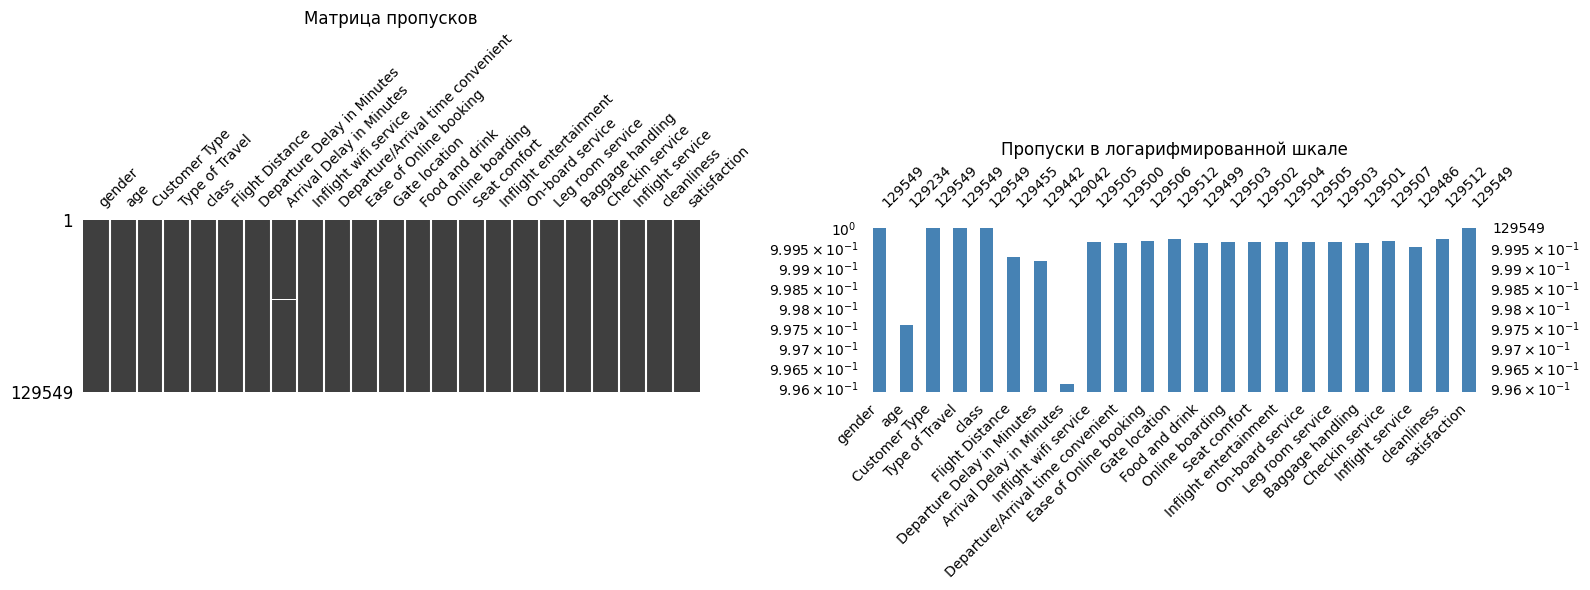

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

missingno.matrix(df, ax=axes[0], fontsize=10, sparkline=False)
axes[0].set_title('Матрица пропусков', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

missingno.bar(df, ax=axes[1], log=True, fontsize=10, color='steelblue')
axes[1].set_title('Пропуски в логарифмированной шкале', fontsize=12)

plt.tight_layout()
plt.show()

Разобьем датасет на тренировочную и тестовую части. Тестовую часть отложим надолго -- до самого конца этого ноутбука.

In [13]:
df_train = df[df.satisfaction != '-']
df_train

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness,satisfaction
id,,,,,,,,,,,,,,,,,,,,,
7,Male,43.0,Loyal Customer,Business travel,Business,1963.0,0.0,0.0,3.0,3.0,...,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,4.0,satisfied
13,Male,24.0,disloyal Customer,Business travel,Eco,453.0,16.0,30.0,2.0,2.0,...,2.0,5.0,5.0,2.0,4.0,4.0,2.0,4.0,5.0,neutral or dissatisfied
18,Female,61.0,Loyal Customer,Personal Travel,Eco,821.0,0.0,0.0,2.0,5.0,...,1.0,5.0,5.0,5.0,2.0,5.0,5.0,5.0,1.0,neutral or dissatisfied
31,Male,35.0,disloyal Customer,Business travel,Business,212.0,0.0,0.0,2.0,2.0,...,2.0,2.0,2.0,4.0,5.0,5.0,5.0,4.0,2.0,neutral or dissatisfied
39,Female,46.0,Loyal Customer,Business travel,Business,67.0,0.0,0.0,3.0,3.0,...,5.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,5.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129831,Female,28.0,Loyal Customer,Personal Travel,Eco,447.0,23.0,16.0,1.0,3.0,...,1.0,3.0,3.0,1.0,1.0,4.0,1.0,5.0,3.0,neutral or dissatisfied
129837,Male,66.0,Loyal Customer,Personal Travel,Eco,337.0,199.0,213.0,2.0,4.0,...,5.0,5.0,5.0,2.0,4.0,5.0,5.0,4.0,5.0,neutral or dissatisfied
129838,Female,59.0,Loyal Customer,Personal Travel,Eco,308.0,32.0,24.0,3.0,5.0,...,5.0,5.0,3.0,3.0,3.0,3.0,4.0,3.0,4.0,neutral or dissatisfied


In [14]:
assert df_train.shape == (103_644, 23)

In [15]:
df_test = df[df.satisfaction == '-'].drop('satisfaction', axis=1)
df_test

,gender,age,Customer Type,Type of Travel,class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness
id,,,,,,,,,,,,,,,,,,,,,
55,Male,36.0,Loyal Customer,Business travel,Business,3655.0,40.0,71.0,1.0,1.0,...,1.0,3.0,3.0,3.0,3.0,3.0,1.0,4.0,3.0,2.0
79,Female,70.0,Loyal Customer,Personal Travel,Eco,108.0,50.0,41.0,5.0,4.0,...,4.0,4.0,4.0,3.0,3.0,0.0,3.0,5.0,3.0,5.0
126,Male,66.0,Loyal Customer,Personal Travel,Eco,562.0,88.0,84.0,2.0,5.0,...,5.0,2.0,5.0,5.0,3.0,5.0,2.0,5.0,5.0,5.0
199,Female,60.0,Loyal Customer,Business travel,Business,3756.0,36.0,24.0,4.0,4.0,...,2.0,4.0,5.0,4.0,4.0,4.0,4.0,5.0,4.0,5.0
263,Male,43.0,Loyal Customer,Personal Travel,Business,802.0,0.0,0.0,1.0,2.0,...,2.0,3.0,3.0,2.0,2.0,1.0,2.0,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129750,Male,38.0,Loyal Customer,Business travel,Eco,337.0,92.0,82.0,4.0,3.0,...,4.0,5.0,4.0,4.0,4.0,5.0,4.0,5.0,3.0,4.0
129771,Male,16.0,Loyal Customer,Personal Travel,Eco,308.0,2.0,0.0,3.0,4.0,...,1.0,3.0,5.0,1.0,4.0,2.0,5.0,5.0,4.0,1.0
129798,Female,43.0,Loyal Customer,Personal Travel,Eco,308.0,0.0,0.0,2.0,4.0,...,3.0,5.0,5.0,4.0,4.0,2.0,4.0,4.0,4.0,5.0


In [16]:
assert df_test.shape == (25_905, 22)

Разбиваем данные на трейн и валидацию. Не меняйте сид

In [17]:
X_train, X_val, y_train, y_val = train_test_split(df_train.drop('satisfaction', axis=1), df_train.satisfaction, test_size=0.3, random_state=42)

In [18]:
assert X_train.shape == (72_550, 22)
assert X_val.shape == (31_094, 22)

### **Задание 4. (0.15 балла)**

Заполните пропуски в данных наиболее часто встречающимся значением.
Помните про правильность заполнения.

**Примечание:** Мы также могли восстановать пропуски `KNNImputer`'ом или `IterativeImputer`'ом. Как правило, такое заполнение точнее и лучше сохраняет структуру распределений. Но для признаков в нашей задаче Imputer'ы, реализованные библиотечно не подошли бы. Они возвращали бы вещественные значения, а в нашей задаче все признаки целые.

In [19]:
imputer = SimpleImputer(strategy='most_frequent')

numeric_cols = X_train.select_dtypes(include=[np.number]).columns

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

df_test = pd.DataFrame(
    imputer.transform(df_test),
    columns=df_test.columns,
    index=df_test.index
)

for col in numeric_cols:
    X_train[col] = pd.to_numeric(X_train[col])
    X_val[col] = pd.to_numeric(X_val[col])
    df_test[col] = pd.to_numeric(df_test[col])


In [20]:
X_train["Customer Type"].value_counts()

,count
Customer Type,
Loyal Customer,59354
disloyal Customer,13144
nan,52


Кроме того, у нас может быть ситуация, когда nan лежит строкой, поэтому заменим все такие значеия тоже

In [21]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        most_frequent = X_train[col][X_train[col] != 'nan'].mode()[0]
        X_train[col] = X_train[col].replace('nan', most_frequent)
        X_val[col] = X_val[col].replace('nan', most_frequent)
        df_test[col] = df_test[col].replace('nan', most_frequent)

### **Задание 5. (0.1 балла)**

- Выведите основные статистики по числовым и категориальным столбцам таблицы
- Сделайте **текстовый** вывод о распределениях значений признаков

In [22]:
X_train.describe(include=['object'])

,gender,Customer Type,Type of Travel,class
count,72550,72550,72550,72550
unique,2,2,2,3
top,Female,Loyal Customer,Business travel,Business
freq,36816,59406,50054,34793


In [23]:
X_train.describe()

,age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,cleanliness
count,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000,72550.000000
mean,40.098856,1329.018332,15.859366,16.645968,2.733687,3.065017,2.761006,2.982688,3.209318,3.256513,3.445665,3.362150,3.383101,3.352364,3.630255,3.309056,3.640234,3.291178
std,20.658196,4764.369357,70.861937,97.990293,1.362172,1.552254,1.414843,1.316648,1.349963,1.372739,1.346077,1.360862,1.333758,1.360180,1.227853,1.293114,1.215114,1.343302
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,413.000000,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000
max,544.000000,379620.000000,9282.000000,11760.000000,45.000000,45.000000,28.000000,36.000000,36.000000,32.000000,45.000000,40.000000,45.000000,36.000000,40.000000,45.000000,36.000000,45.000000


In [24]:
X_train["gender"].value_counts()

,count
gender,
Female,36816
Male,35734


In [25]:
X_train["Customer Type"].value_counts()

,count
Customer Type,
Loyal Customer,59406
disloyal Customer,13144


In [26]:
X_train["Type of Travel"].value_counts()

,count
Type of Travel,
Business travel,50054
Personal Travel,22496


In [27]:
X_train["class"].value_counts()

,count
class,
Business,34793
Eco,32546
Eco Plus,5211


Категориальные признаки:
- `gender`. Две категории: Male и Female, примерно равны по количеству
- `Customer Type`. Две категории, `Loyal Customer` сильно примерно в 5 раз превосходит по количеству `disloyal Customer`
- `Tyoe of Travel`. Две категории - `Business Travel` примерно в 2 раза превосходит по количеству `Personal Travel`.
- `class` - 3 категории. Примерно равные `Business` и `Eco` и довольно редкая `Eco plus`.


В числовых признаках наблюдаются явные выбросы в фичах: `age`, `Flight Distance`, `Departure/Arrival Delay in Minutes`

### **Задание 6 (0.25 балла)**

- Удалите строки c выбросами в числовых столбцах (для трейна и валидации; тест оставьте без изменений).

**Примечание:** Выбросами считайте значения признака, строго превышающие 0.996-квантиль.

По определению, квантиль — значение, которое заданная случайная величина не превышает с фиксированной вероятностью. То есть, если мы смотрим на квантиль 0.996-квантиль, то значения после этого квантиля встречаются в 0.004% случаев. В среднем для всех признаков эти значения начинаются ~в этом квантиле.



In [28]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
bounds = X_train[numeric_cols].quantile(0.996)

outliers_train = (X_train[numeric_cols] > bounds).any(axis=1)
outliers_val = (X_val[numeric_cols] > bounds).any(axis=1)

X_train, y_train = X_train[~outliers_train], y_train[~outliers_train]
X_val, y_val = X_val[~outliers_val], y_val[~outliers_val]

In [29]:
assert df_test.shape == (25_905, 22)

## **1. 2. EDA (1 балл)**

Создадим переменные с перечислениями столбцов разного типа

In [30]:
continuous_cols = ['age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
ordinal_cols = list(set(df.select_dtypes(include='number').columns) - set(continuous_cols))
categorical_cols = list(df.select_dtypes(include='object').columns)[:-1]

In [31]:
assert len(continuous_cols + ordinal_cols + categorical_cols) == 22

### **Задание 7. (0.3 балла)**

- Напишите процедуры для отрисовки графиков;
 * Для признаков, которые мы выделили как порядковые и для категориальных, отображайте только `countplot`
  * Для тех, что считаем континуальными, -- гистограмму распределения признака и ящик с усами (inline)

- Вызовите все 3 написанные процедуры для соответствующих колонок `X_train`. Отдельно визуализируйте распределение таргета в трейне. Всё должно красиво работать! :)

**Примечание 1:**

Помните про хороший тон визуализации — все графики и их оси обязательно должны быть подписаны, легенда на графике также необходима! За неё также могут быть сняты баллы.

**Примечание 2:**

Обязательно выделяйте таргет разными цветами. Мы же хотим в конечном итоге понять, чем удовлетворенные клиенты отличаются от недовольных.

In [32]:
def plot_ordinal(cols, df, y):
    """Draws countplots for all columns in 'cols' with informative title"""
    for col in cols:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col, hue=y, palette='viridis')
        plt.title(f'Распределение {col} по уровням удовлетворенности', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.legend(title='Satisfaction', labels=['neutral/dissatisfied', 'satisfied'])
        plt.tight_layout()
        plt.show()


In [33]:
def plot_continuous(cols, df, y):
    """Draws kdeplots and boxplots in one row
    for all columns in 'cols' with informative title
    """
    for col in cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for target_value in y.unique():
            subset = df[y == target_value]
            sns.histplot(subset[col], kde=True, label=target_value, alpha=0.5, ax=axes[0])
        axes[0].set_title(f'Распределение {col}', fontsize=14)
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Плотность')
        axes[0].legend()

        plot_df = df.copy()
        plot_df['satisfaction'] = y
        sns.boxplot(data=plot_df, x='satisfaction', y=col, palette='viridis', hue='satisfaction', ax=axes[1])
        axes[1].set_title(f'Ящик с усами для {col}', fontsize=14)
        axes[1].set_xlabel('Удовлетворенность')
        axes[1].set_ylabel(col)

        plt.tight_layout()
        plt.show()

In [34]:
def plot_categorical(cols, df, y):
    """Draws countplots for all columns in 'cols' with informative title"""
    for col in cols:
        if col in df.columns:
            plt.figure(figsize=(10, 5))
            data = df.copy()
            data['target'] = y

            order = df[col].value_counts().index
            sns.countplot(data=data, x=col, hue='target', order=order, palette='viridis')
            plt.title(f'Распределение {col} по уровням удовлетворенности', fontsize=14)
            plt.xlabel(col)
            plt.ylabel('Количество')
            plt.legend(title='Satisfaction', labels=['neutral/dissatisfied', 'satisfied'])
            plt.xticks(rotation=45 if len(df[col].unique()) > 3 else 0)
            plt.tight_layout()
            plt.show()

Отрисовка.

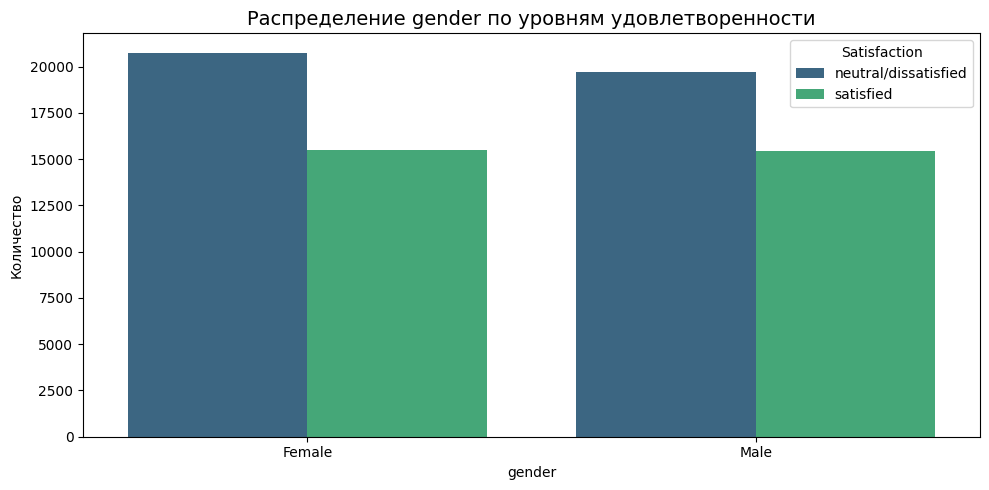

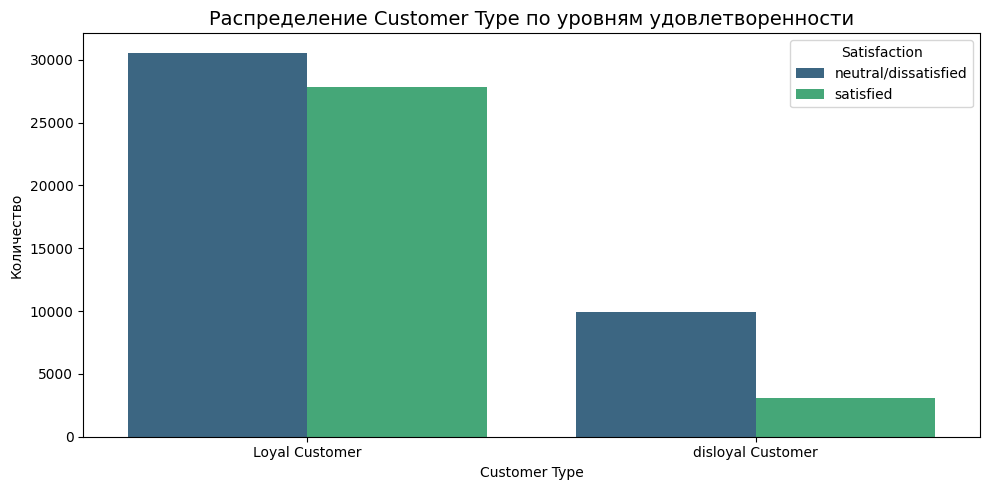

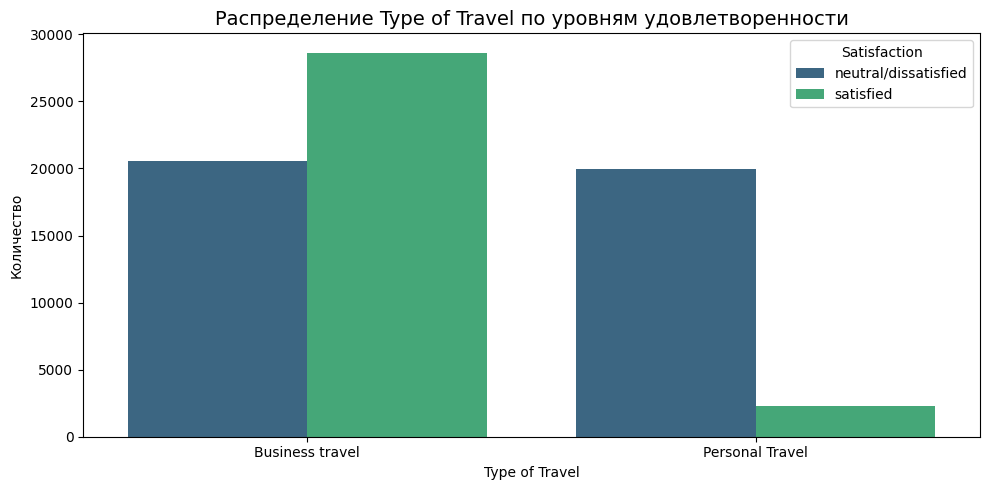

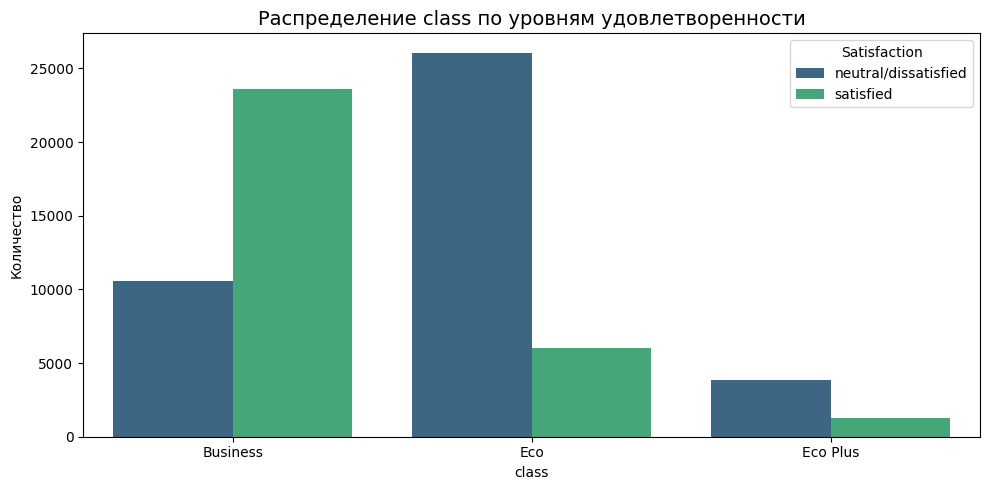

In [34]:
plot_categorical(categorical_cols, X_train, y_train)

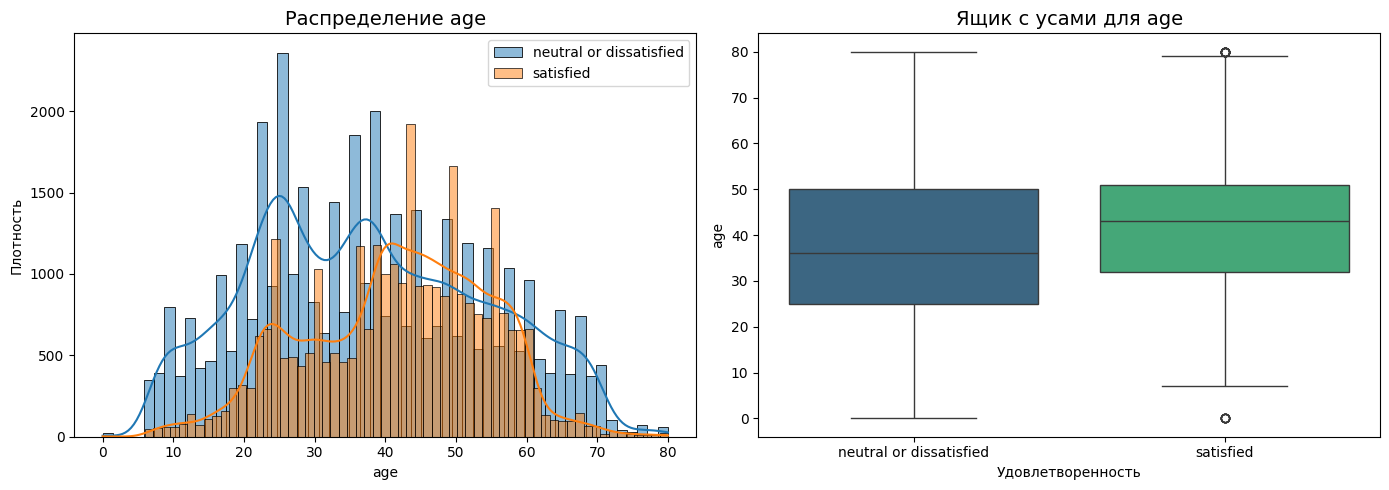

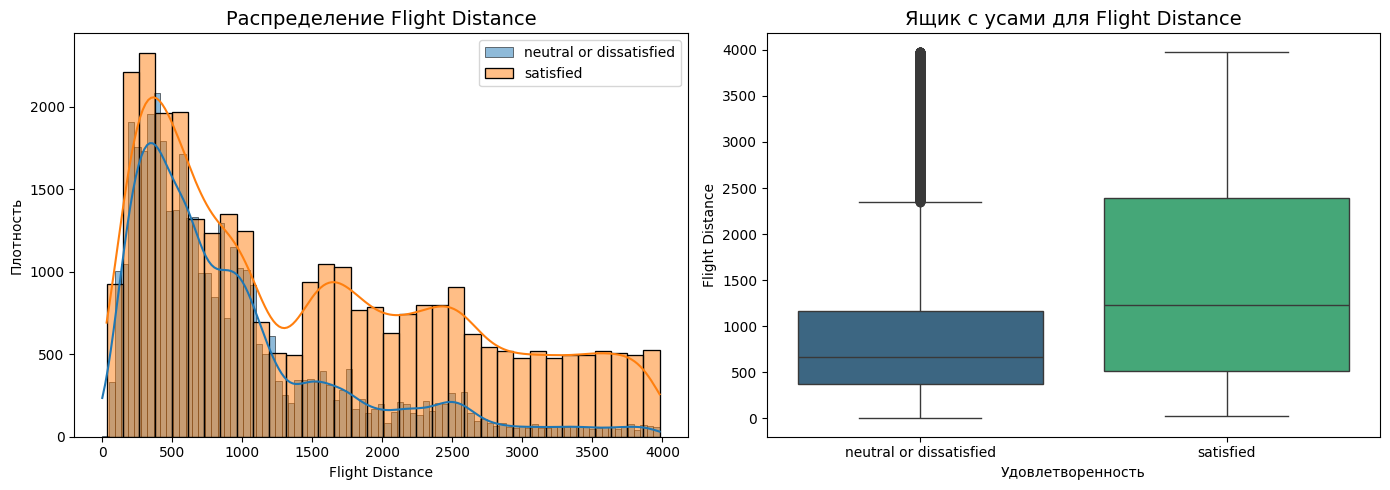

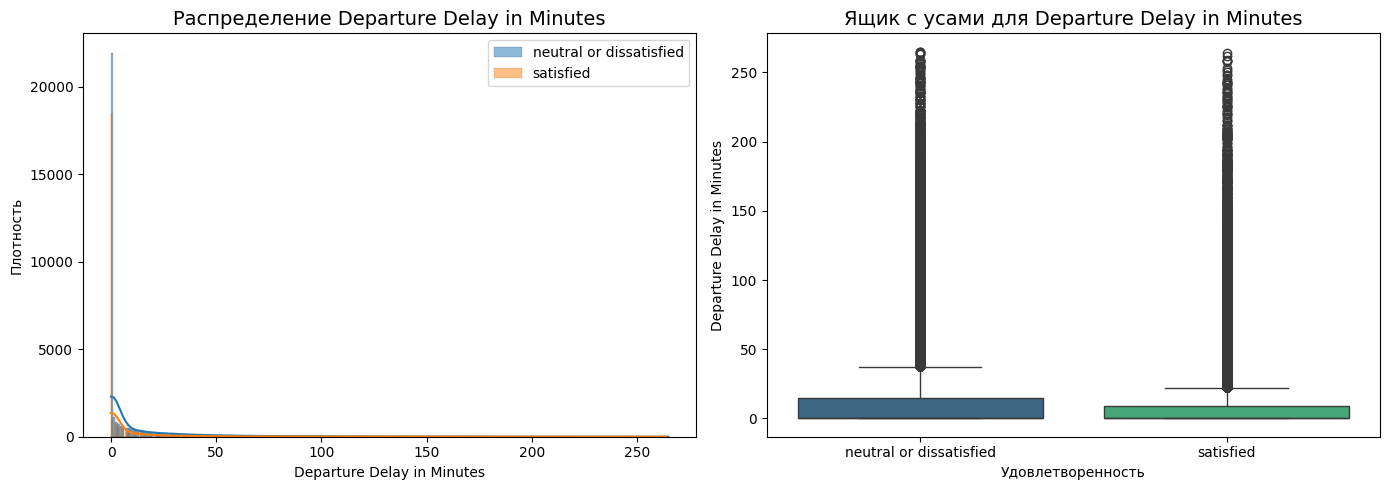

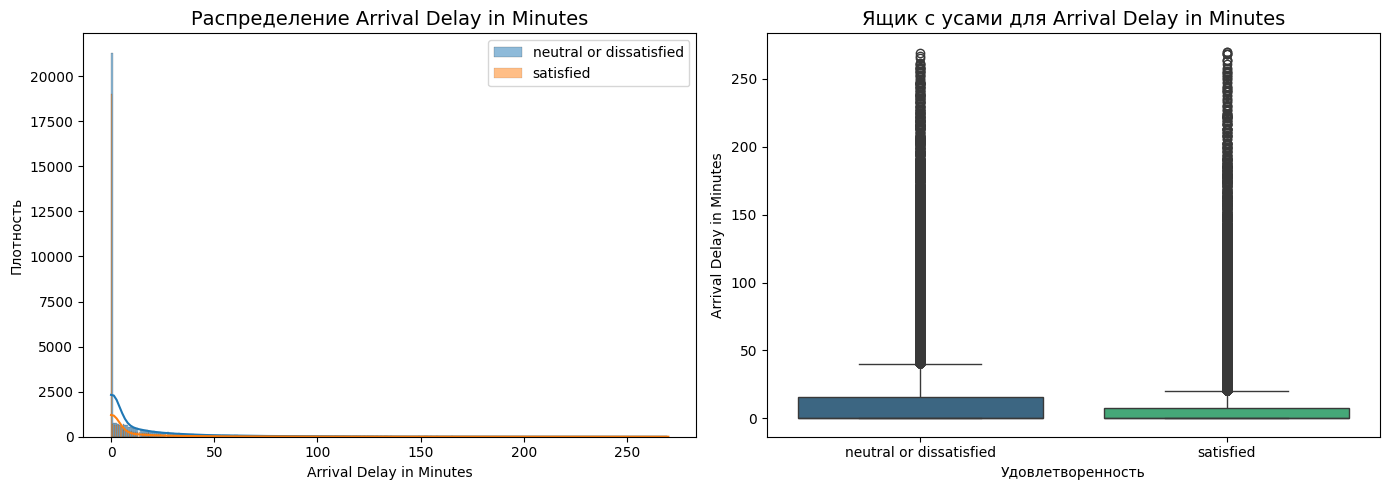

In [35]:
plot_continuous(continuous_cols, X_train, y_train)

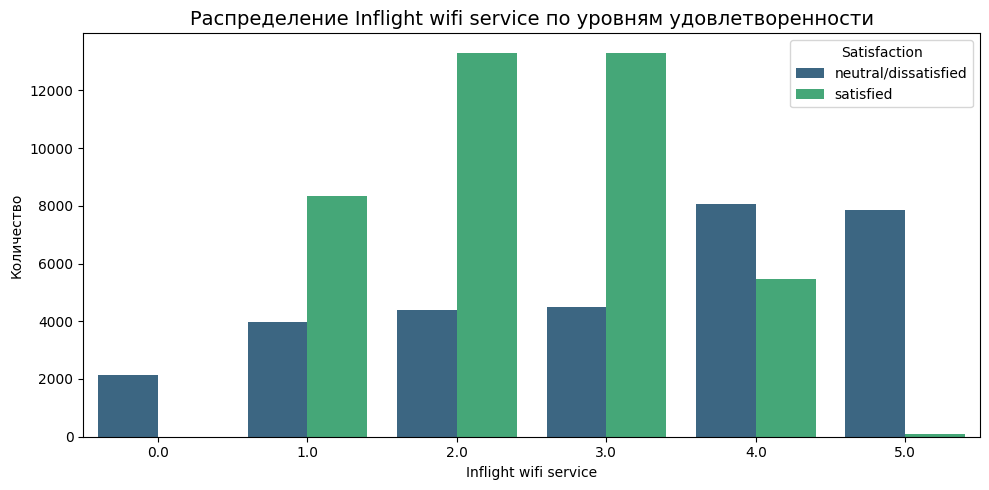

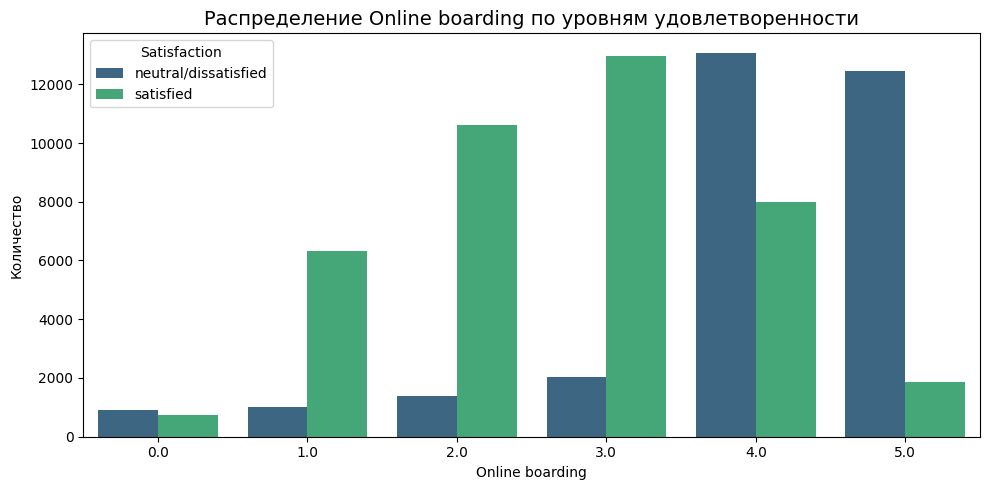

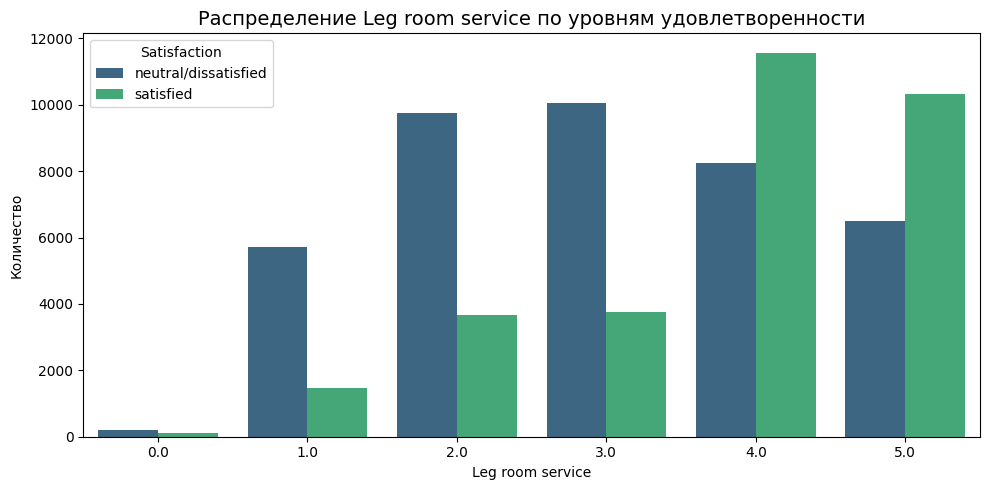

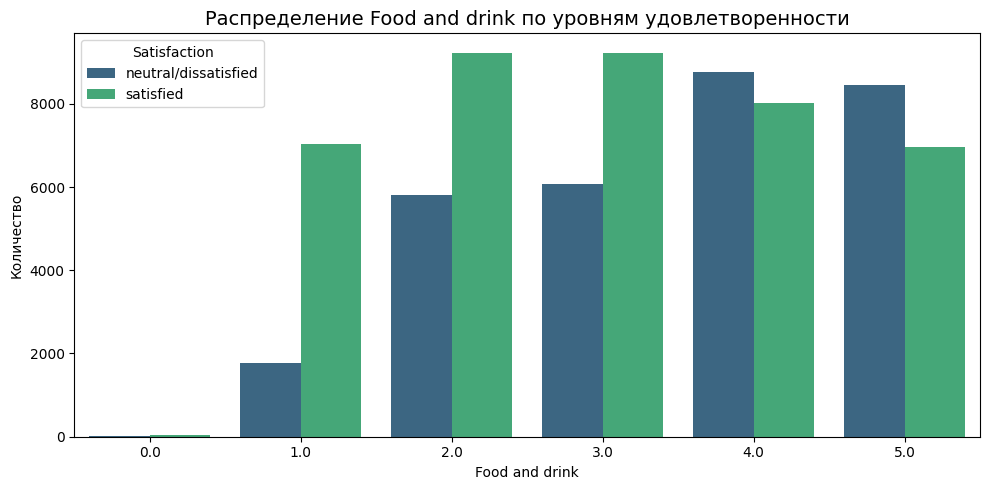

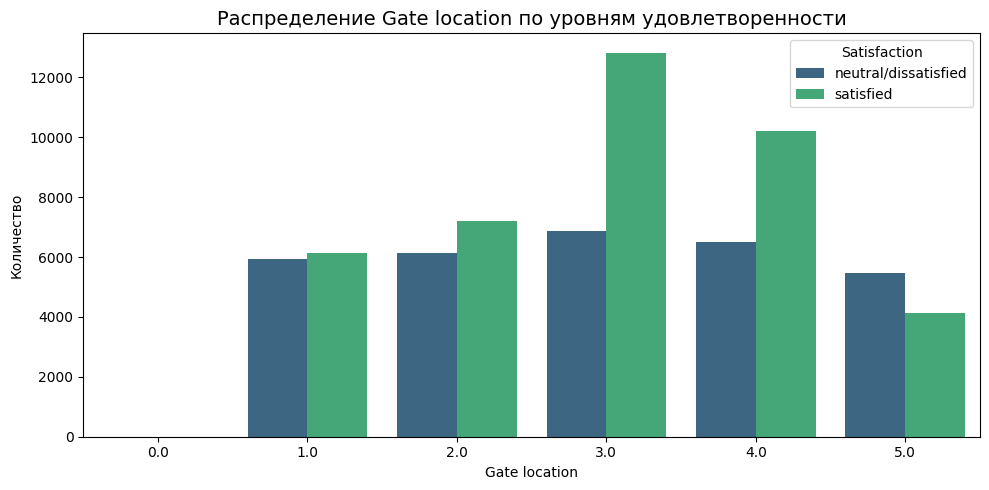

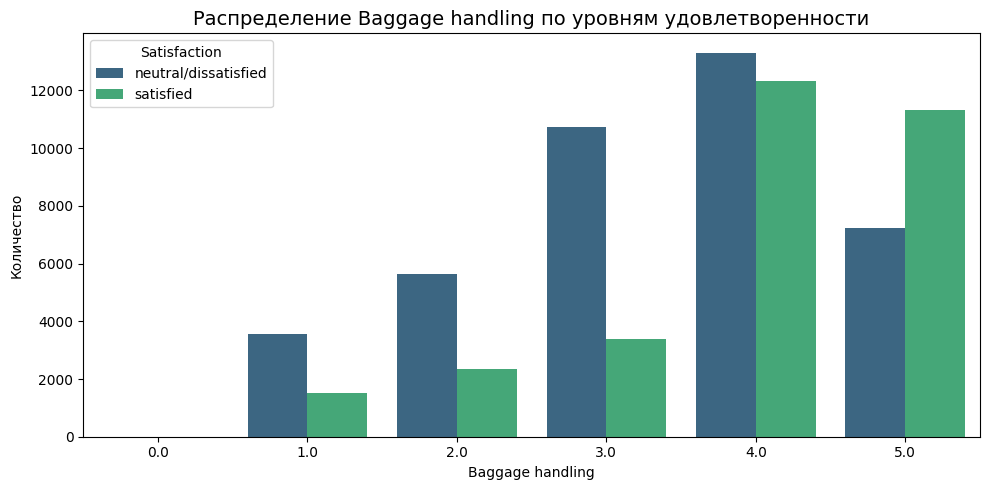

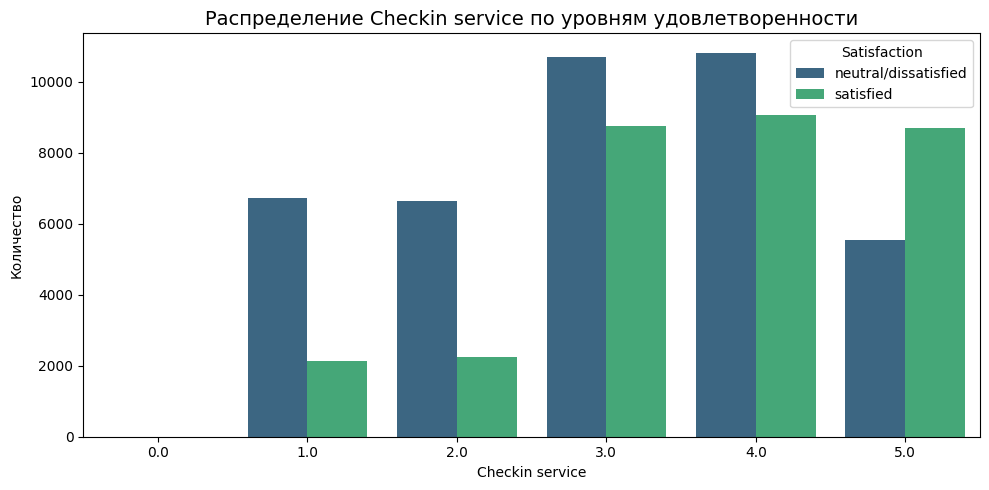

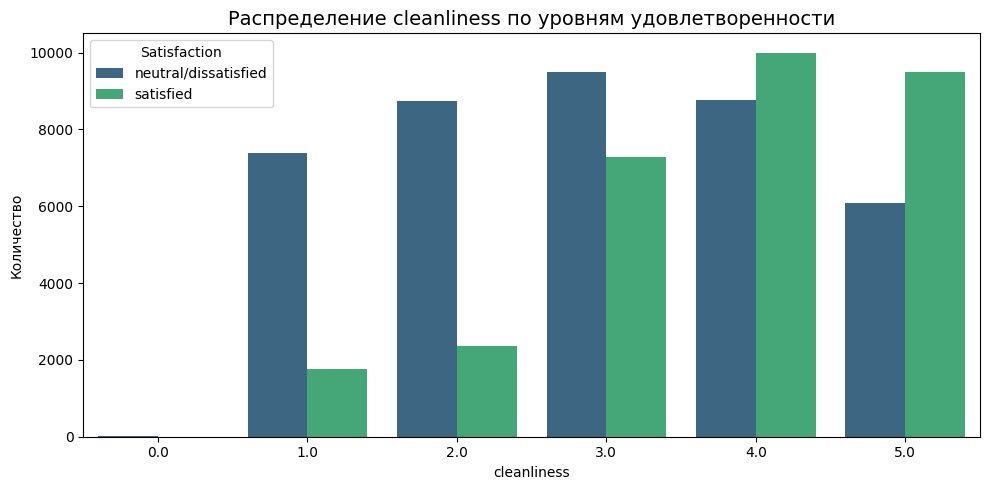

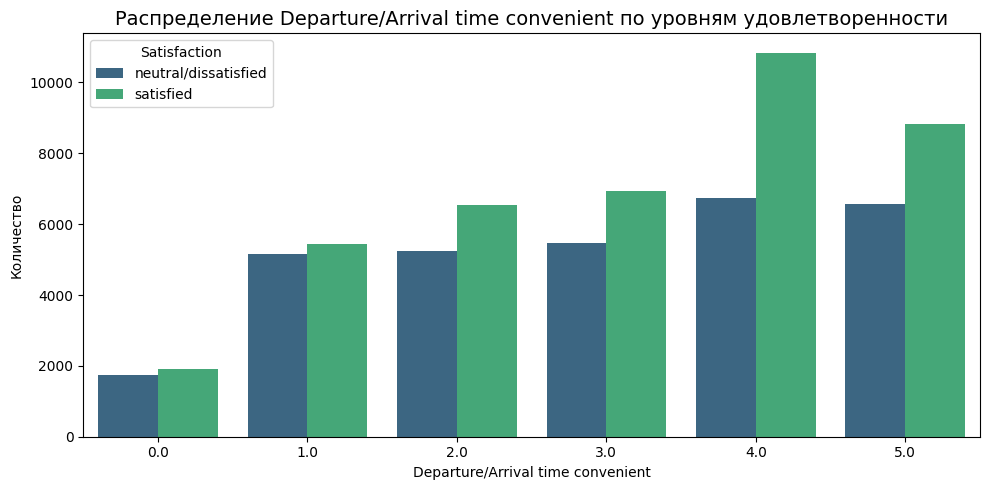

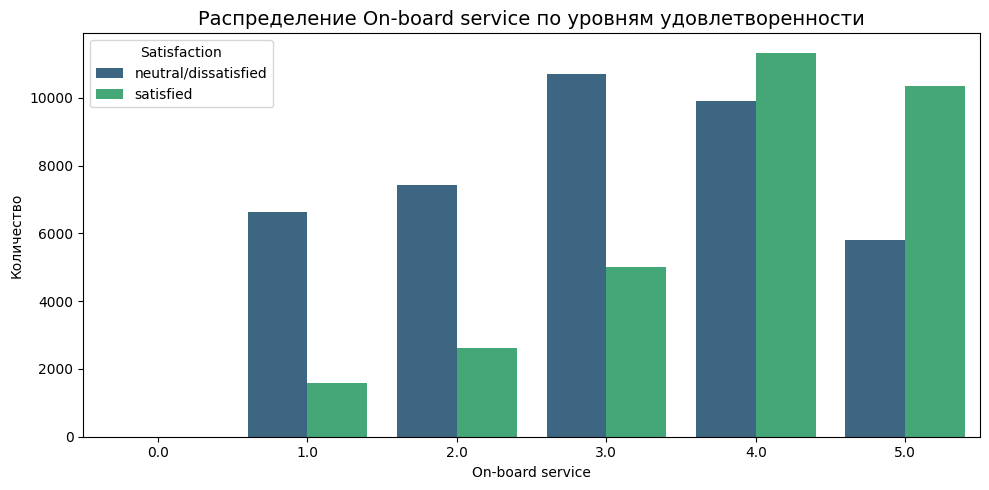

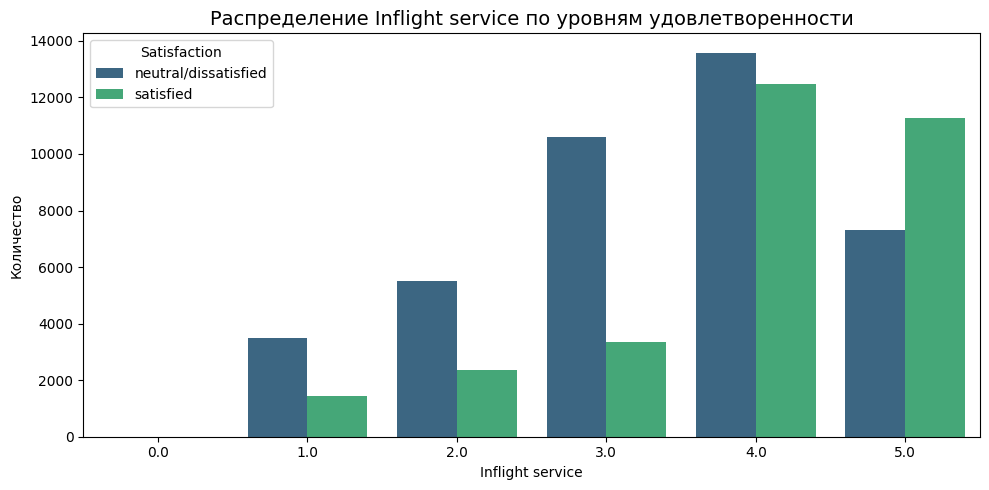

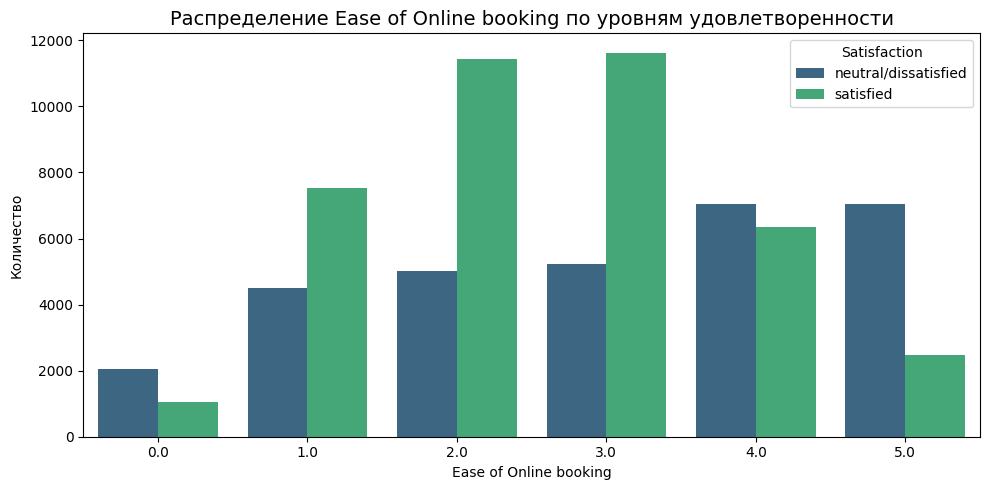

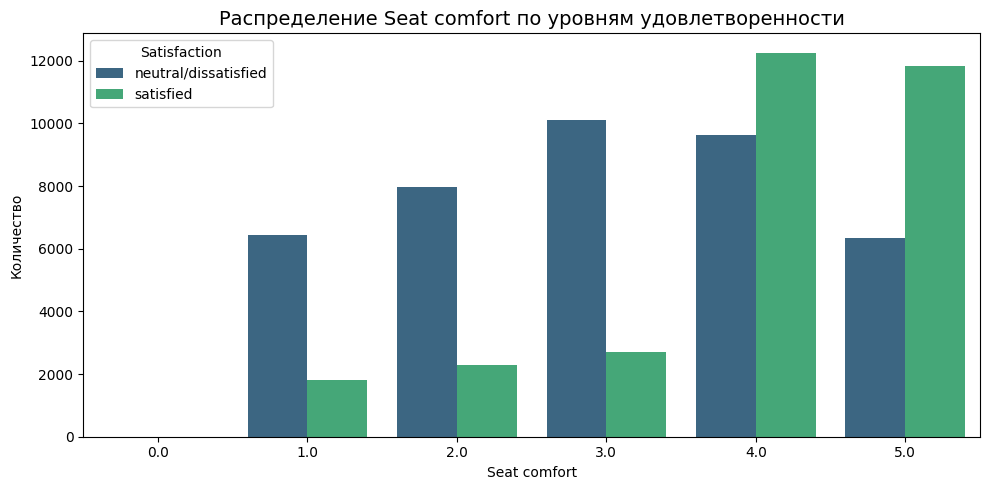

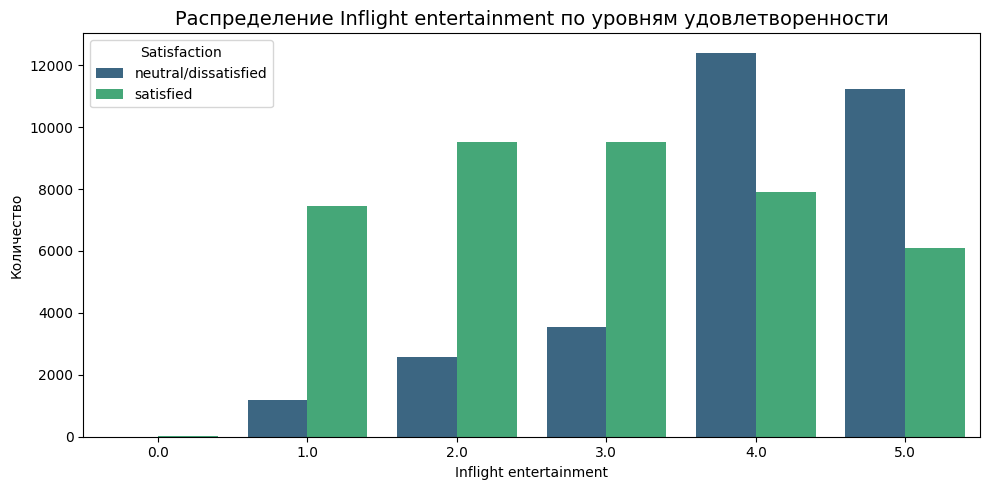

In [36]:
plot_ordinal(ordinal_cols, X_train, y_train)

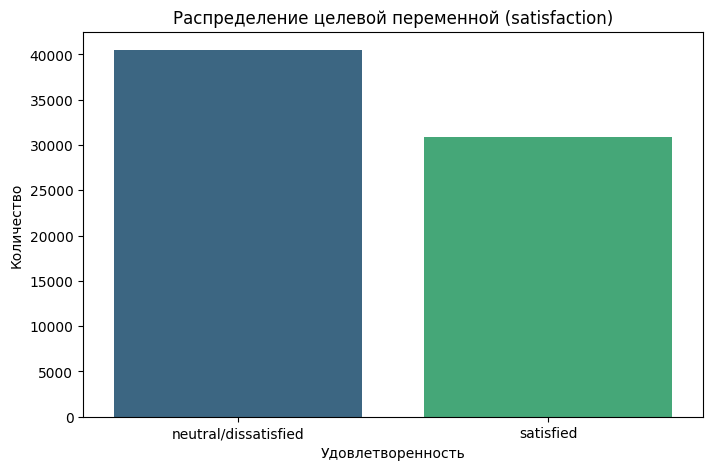

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train, hue=y_train, palette='viridis', legend=False)
plt.title('Распределение целевой переменной (satisfaction)')
plt.xlabel('Удовлетворенность')
plt.ylabel('Количество')
plt.xticks([0, 1], ['neutral/dissatisfied', 'satisfied'])
plt.show()

### **Задание 8 (0.2 балла)**

Сделайте выводы по построенным графикам.

Не забудьте упомянуть:
* какие признаки распределены неравномерно
* сбалансированы ли классы
* какие распределения имеют континуальные признаки

- Фича `gender` сбалансирована и распределена одинаково для обоих классов
- `Customer type` не сбалансирована - `loyal cutomer`-ов сильно больше и они распеделны одинаково по лояльности, `disloyal customers`, как правило, чаще неудовлетворены
- Люди, у которых `Type of travel` - `Business`, обычно чаще удовлетворены, чем те, у которых `Personal travel`, при одинаковой неудовлетворенности
- Люди, у которых `class` - `Business`, как правило, удовлетворены поездкой, а те, у которых `Eco class` или `Eco plus` - нет
- Люди в возрасте до 40 и после 60 чаще неудовлетворены поездкой, а после 40 и до 60 - удовлетворены

### **Бонус (0.1 балла)**
По графикам (каким, решите сами) оцените, похожи ли оказались распределения признаков при разбиении на трейн, валидацию и тест.

In [ ]:
# Ваш код ниже


### **Задание 9 (0.25 балла)**

- Замените признаки "Departure Delay in Minutes" и "Arrival Delay in Minutes" на их логарифмы.
- Заново постройте графики континуальных признаков и сделайте вывод по преобразованию

Некоторые признаки полезно рассматривать в логарифмической шкале. Зачем? Она помогает анализировать большие диапазоны изменений (посмотрите на график логарифма).


In [36]:
X_train['Departure Delay in Minutes'] = np.log1p(X_train['Departure Delay in Minutes'])
X_train['Arrival Delay in Minutes'] = np.log1p(X_train['Arrival Delay in Minutes'])

Построение.

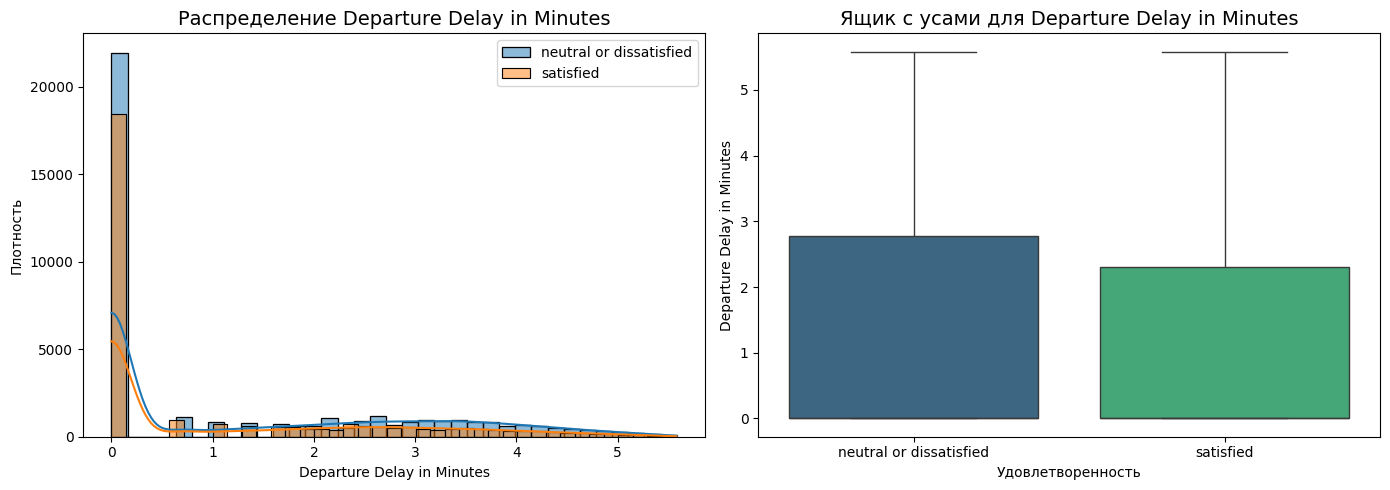

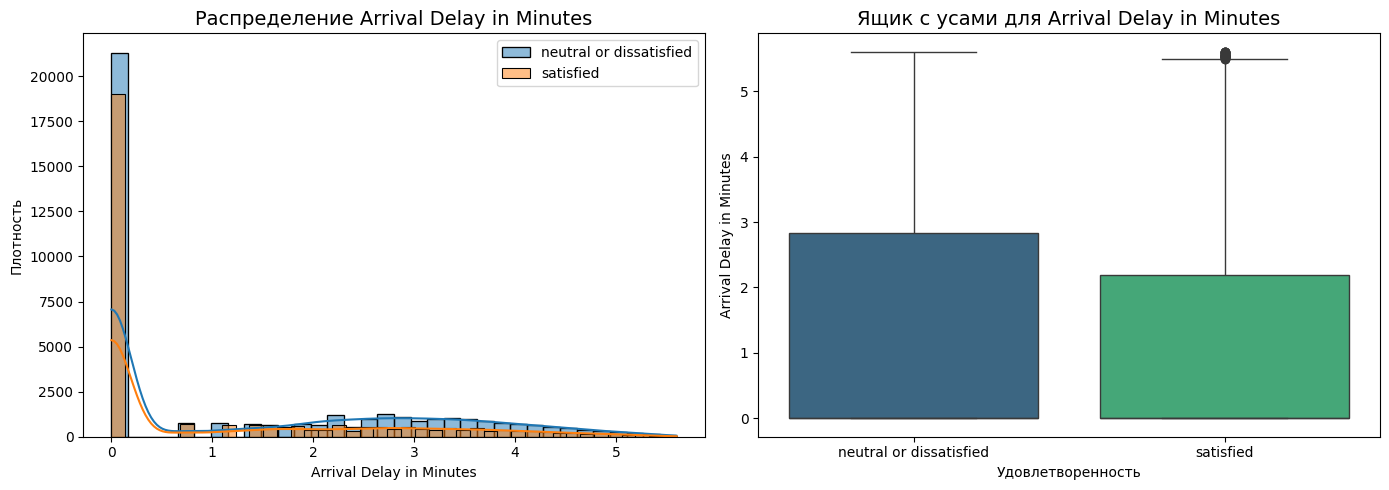

In [37]:
plot_continuous(['Departure Delay in Minutes', 'Arrival Delay in Minutes'], X_train, y_train)

Теперь график стал более наглядным и можно сказать, что чем выше задержка, тем выше вероятность, что человек будет недоволен полетом, если смотреть в соответствующих пропорциях.

### **Задание 10 (0.25 балла)**

Выше вы рассмотрели `boxplot` и графики распределений. Но иногда полезным оказывается `scatterplot, (pairplot)` в seabron. Проверьте, что покажет этот график в нашей задаче.

- Отобразите попарное распределение континуальных (по договоренности) признаков. Покрасьте точки на pairplot'е в соответствии с их классом.

**Примечание:**
Наблюдений много, так что отрисовка графика вполне может занять несколько минут

<Figure size 1600x1200 with 0 Axes>

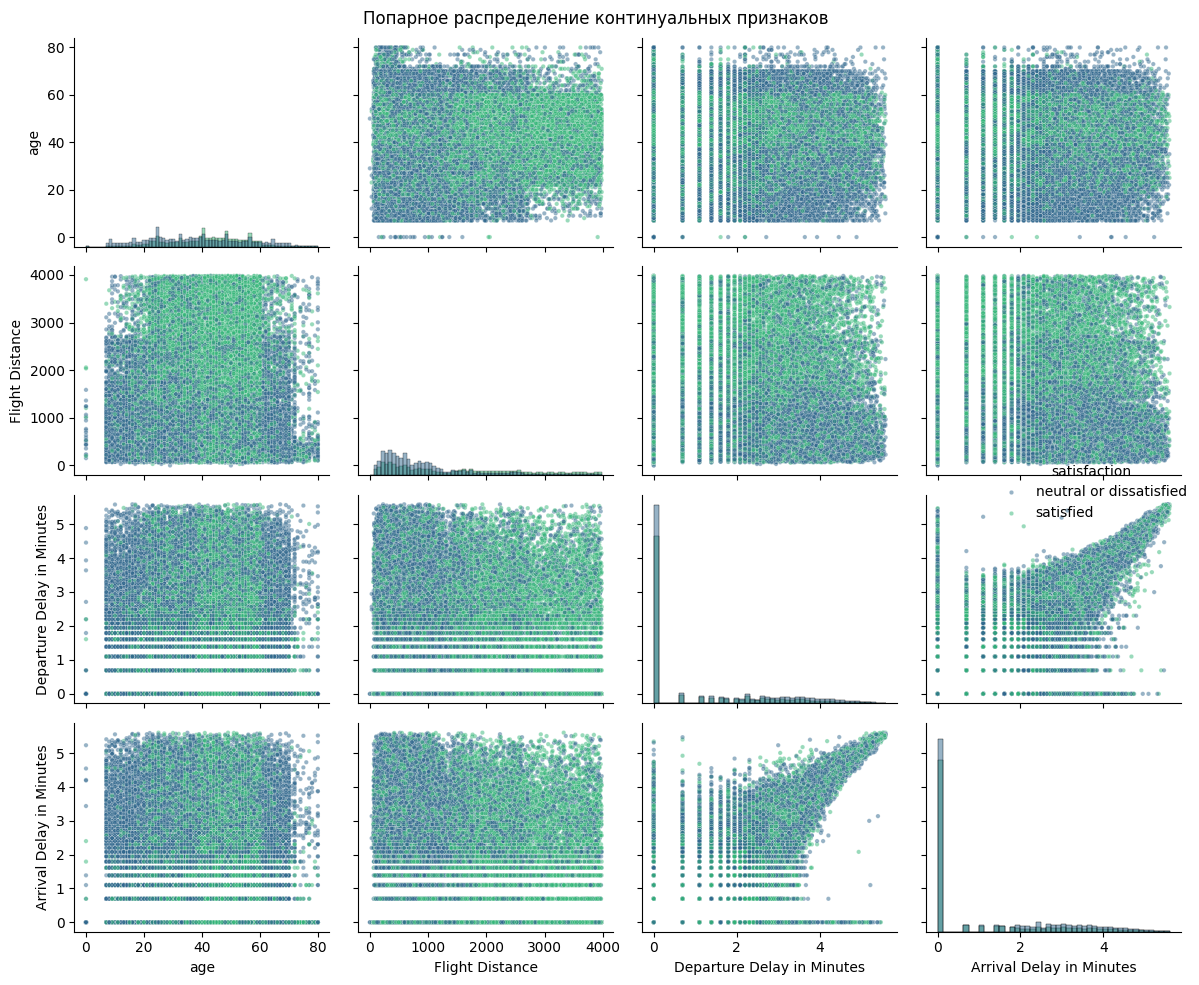

In [38]:
pairplot_df = X_train[continuous_cols].copy()
pairplot_df['satisfaction'] = y_train

plt.figure(figsize=(16, 12))
g = sns.pairplot(
    data=pairplot_df,
    vars=continuous_cols,
    hue='satisfaction',
    palette='viridis',
    diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 10},
    diag_kws={'alpha': 0.5}
)

g.fig.suptitle('Попарное распределение континуальных признаков')
plt.tight_layout()
plt.show()

# **Часть 2. Decision Tree (3 балла)**

### **Задание 11 (0.4 балла)**

Предобработайте данные для алгоритма.
- Закодируйте таргет таким образом, чтоб 'satisfied' перешел в 1, а остальные значения в 0;
- Закодируйте категориальные признаки методом OHE;

In [39]:
y_train_ohe = (y_train == 'satisfied').astype(int)
y_val_ohe = (y_val == 'satisfied').astype(int)

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat = pd.DataFrame(
    ohe.fit_transform(X_train[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_train.index
)

X_val_cat = pd.DataFrame(
    ohe.transform(X_val[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_val.index
)

numeric_cols = [col for col in X_train.columns if col not in categorical_cols]
X_train_ohe = pd.concat([X_train[numeric_cols], X_train_cat], axis=1)
X_val_ohe = pd.concat([X_val[numeric_cols], X_val_cat], axis=1)

### **Задание 12. (0.1 балла)**

- Обучите дерево решений с параметрами по умолчанию на имеющихся данных.
- Выведите `accuracy_score` для валидационной подвыборки

**Примечание**:

Здесь и далее, где вас просят что-нибудь обучить, выводите **везде** `accuracy_score` для валидационной подвыборки.

In [40]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train_ohe, y_train_ohe)

y_pred = decision_tree.predict(X_val_ohe)
print(f"accuracy_score: {accuracy_score(y_val_ohe, y_pred)}")

accuracy_score: 0.912516339869281


## **Анализ построенной модели**

### **Задание 13. (0.5 балла)**

- Посчитайте bias и variance для построенного дерева. Для этого проще всего вспользоваться функцией `bias_variance_decomp()` из модуля mlxtend. Используйте '0-1_loss'

In [41]:
error_dt, bias_dt, var_dt = bias_variance_decomp(
    decision_tree,
    X_train_ohe.values, y_train_ohe.values,
    X_val_ohe.values, y_val_ohe.values,
    loss='0-1_loss'
)

print(f"Error: {error_dt}")
print(f"Bias:  {bias_dt}")
print(f"Variance: {var_dt}")

Error: 0.08749117647058824
Bias:  0.05225490196078431
Variance: 0.07008856209150327


### **Задание 14. (0.2 балла)**

Проанализируйте структурные характеристики дерева.
- Какой глубины получилось дерево?
- Сколько в нем листьев?

In [42]:
print(f"Глубина дерева: {decision_tree.get_depth()}")
print(f"Количество листьев: {decision_tree.get_n_leaves()}")

Глубина дерева: 33
Количество листьев: 2092


Дерево получилось достаточно глубоким, что может говорить нам о переобучении

### **Задание 15. (0.3 балла)**

Проанализируйте важность признаков, вычисляемую в дереве по построению.

- Выведите на экран barplot, демонстрирующий оценки важности признаков.
- Укажите, какие признаки оказались наиболее информативными?

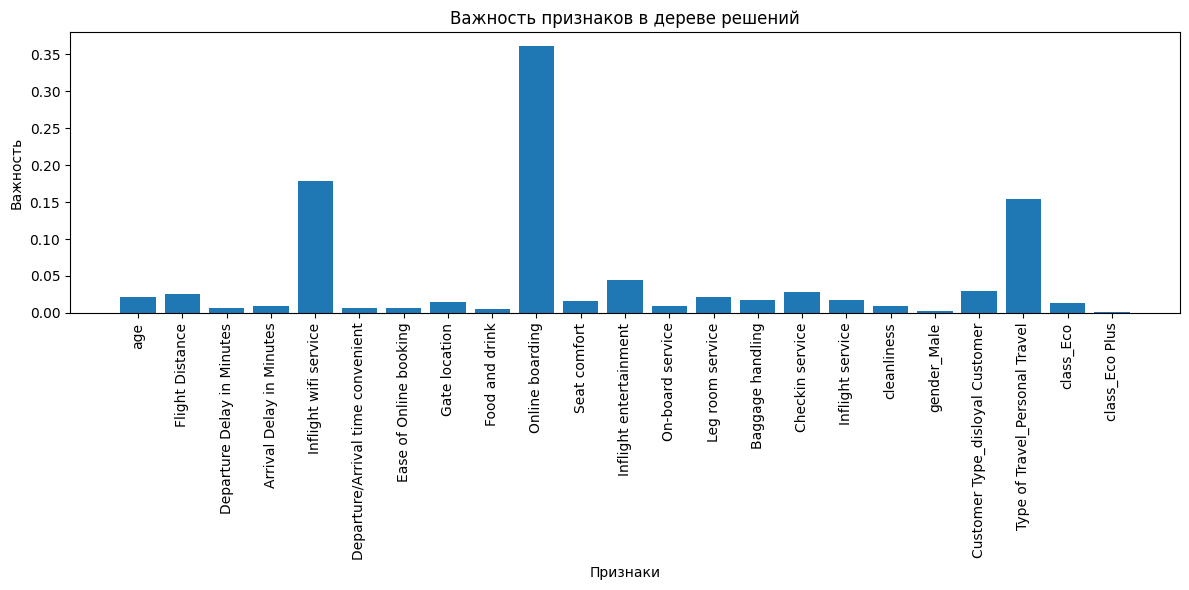

In [43]:
plt.figure(figsize=(12, 6))
plt.bar(range(len(decision_tree.feature_importances_)), decision_tree.feature_importances_)
plt.xticks(range(len(decision_tree.feature_importances_)), X_train_ohe.columns, rotation=90)
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Важность признаков в дереве решений')
plt.tight_layout()
plt.show()

Как видим, самыми выжными признаками оказались:
- Online boarding
- Inflight wifi service
- Type of Travel_Personal Travel

### **Задание 16. (0.1 балла)**

- Постройте дерево глубины 5, используя только 2 наиболее информативных признака для предыдущего построенного дерева.

In [44]:
top_features = ['Online boarding', 'Inflight wifi service']

X_train_top = X_train_ohe[top_features]
X_val_top = X_val_ohe[top_features]

decision_tree = DecisionTreeClassifier(max_depth=5)
decision_tree.fit(X_train_top, y_train_ohe)

y_pred = decision_tree.predict(X_val_top)
print(f"accuracy score: {accuracy_score(y_val_ohe, y_pred)}")

accuracy score: 0.8248366013071895


### **Задание 17. (0.15 балла)**

- С помощью graphviz визуализируйте получившееся новое дерево решений. Почему предикаты в нем не целые, а кратны 1/2?

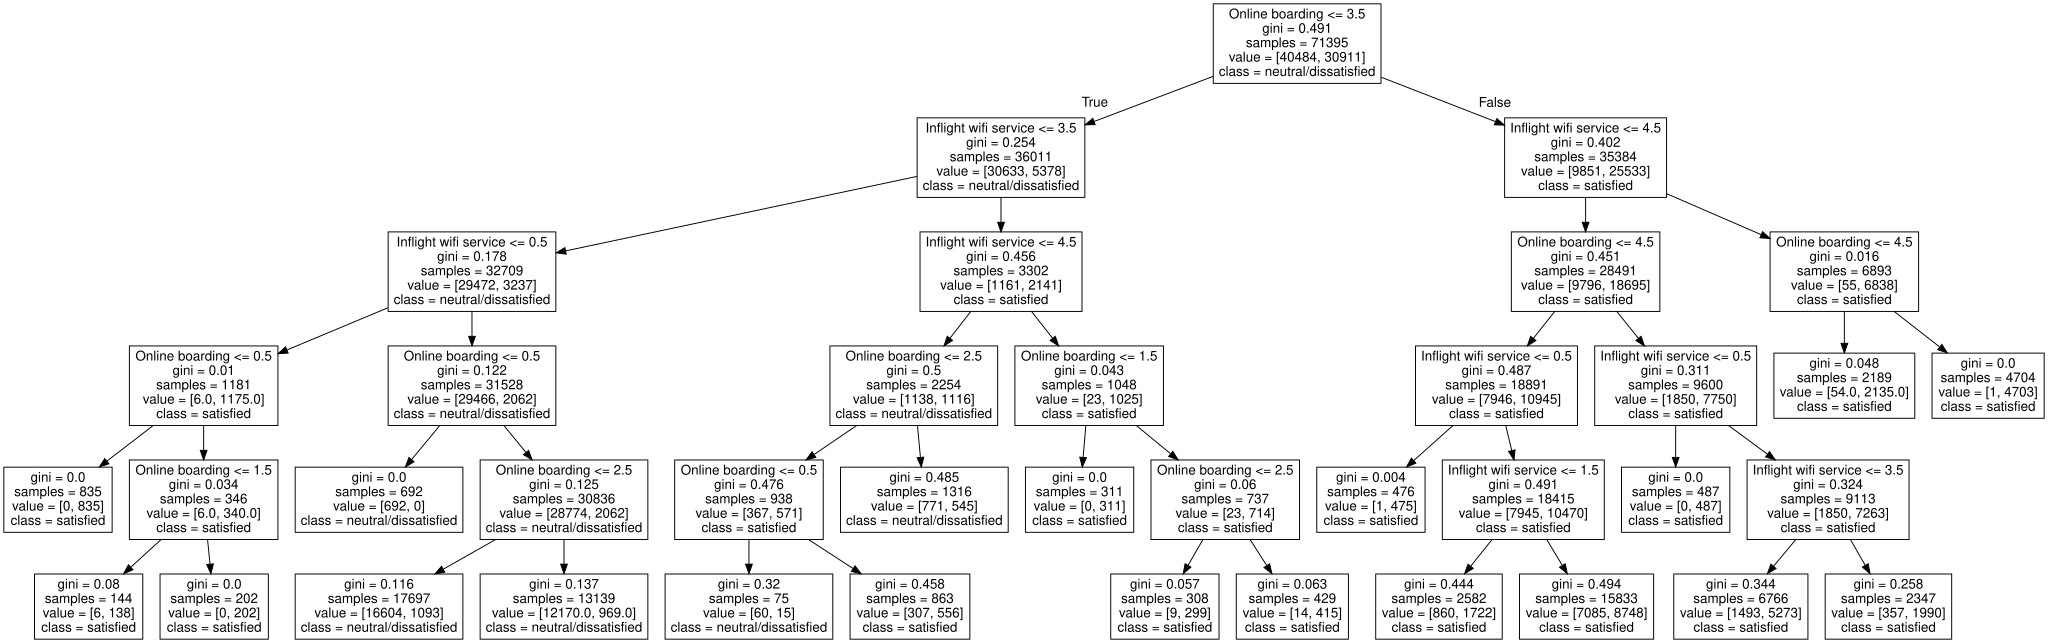

In [45]:
Source(export_graphviz(
    decision_tree,
    feature_names=top_features,
    class_names=['neutral/dissatisfied', 'satisfied']
))

`Online boarding` и `Inflight wifi service` принимают целые значения от 0 до 5, поэтому, чтобы разделить два числа стоящие рядом, например, 2 и 3, необходиом использовать предикат с значением между нимим - 2.5.

### **Задание 18. (0.25 балла)**

- Теперь отобразите его функцией `plot_tree()` из sklearn.
- Проанализируйте — ссимметричным ли получилось дерево? И хорошо ли это, или нет?

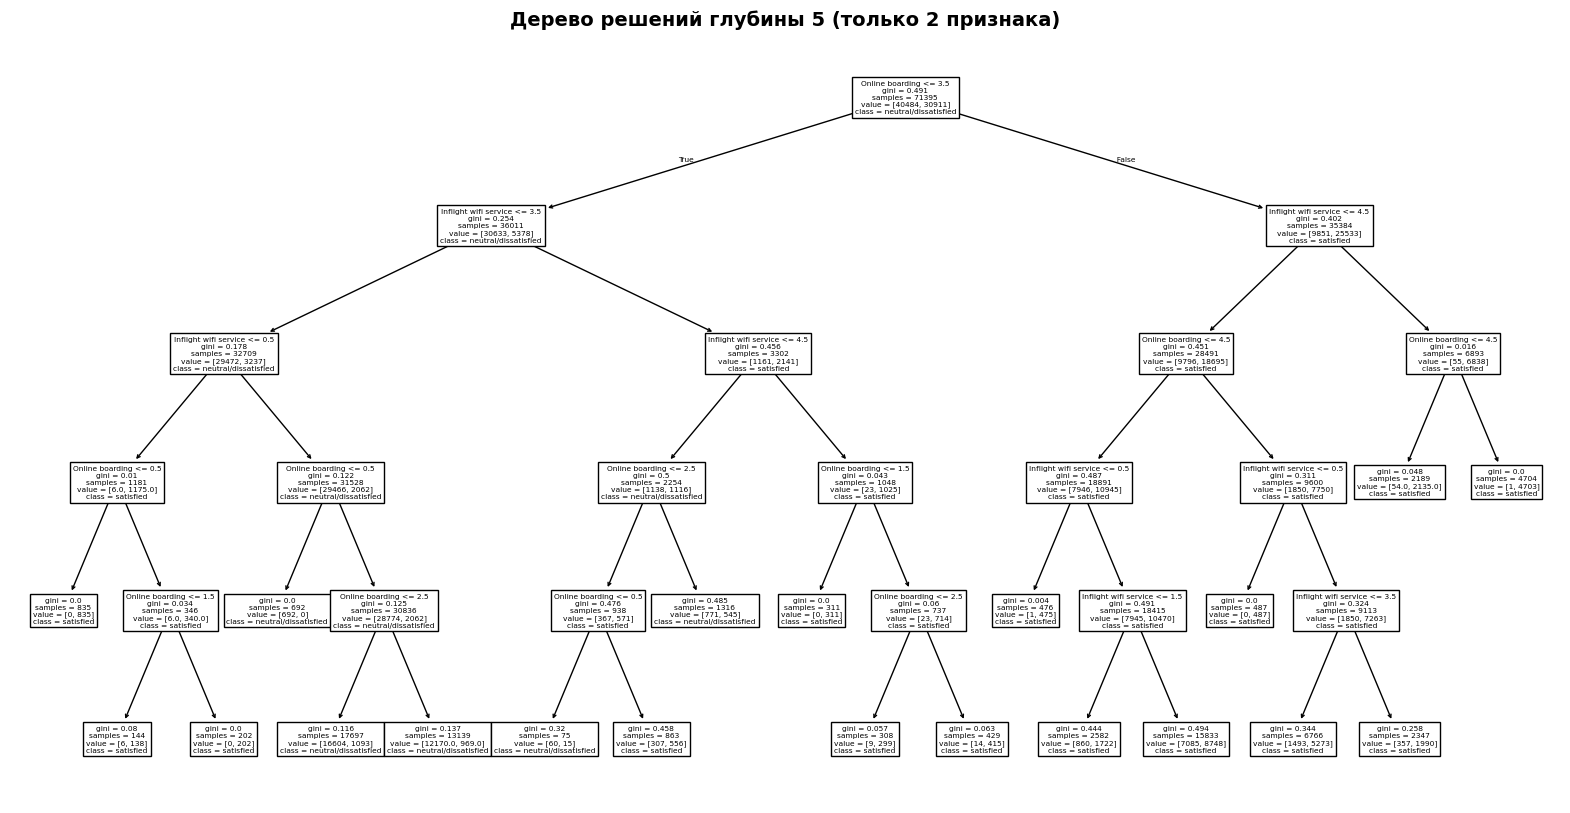

In [46]:
plt.figure(figsize=(20, 10))
plot_tree(
    decision_tree,
    feature_names=top_features,
    class_names=['neutral/dissatisfied', 'satisfied']
)
plt.title('Дерево решений глубины 5 (только 2 признака)', fontsize=14, fontweight='bold')
plt.show()

Дерево получилось несимметричным. Это нормально, посколько данные тоже несимметричны и дерево растет только там, где надо

### **Задание 19. (0.5 балла)**

- Используя функцию `plot_decision_regions()` из `mlxtend`, отобразите разделяющую поверхность получившегося дерева. Отметьте на графике только первые 100 объектов обучающей выборки

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


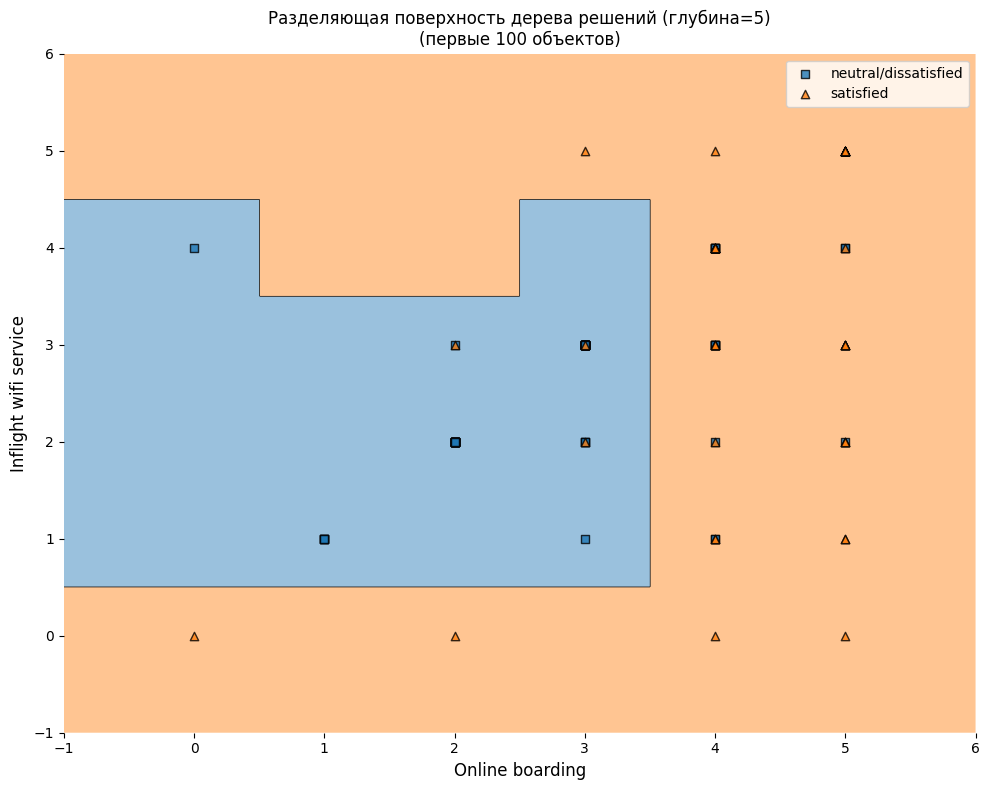

In [47]:
plt.figure(figsize=(10, 8))
plot_decision_regions(X_train_top.values[:100], y_train_ohe[:100].values, clf=decision_tree, legend=2)

plt.xlabel(top_features[0], fontsize=12)
plt.ylabel(top_features[1], fontsize=12)
plt.title('Разделяющая поверхность дерева решений (глубина=5)\n(первые 100 объектов)')
plt.legend(['neutral/dissatisfied', 'satisfied'], loc='upper right')
plt.tight_layout()
plt.show()

### **Деревья решений. Теоретическая вставка**

Из лекций вам должно быть известно, что деревья решений неустойчивы даже к небольшим изменениям в обучающей выборке. Попробуем показать это!

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


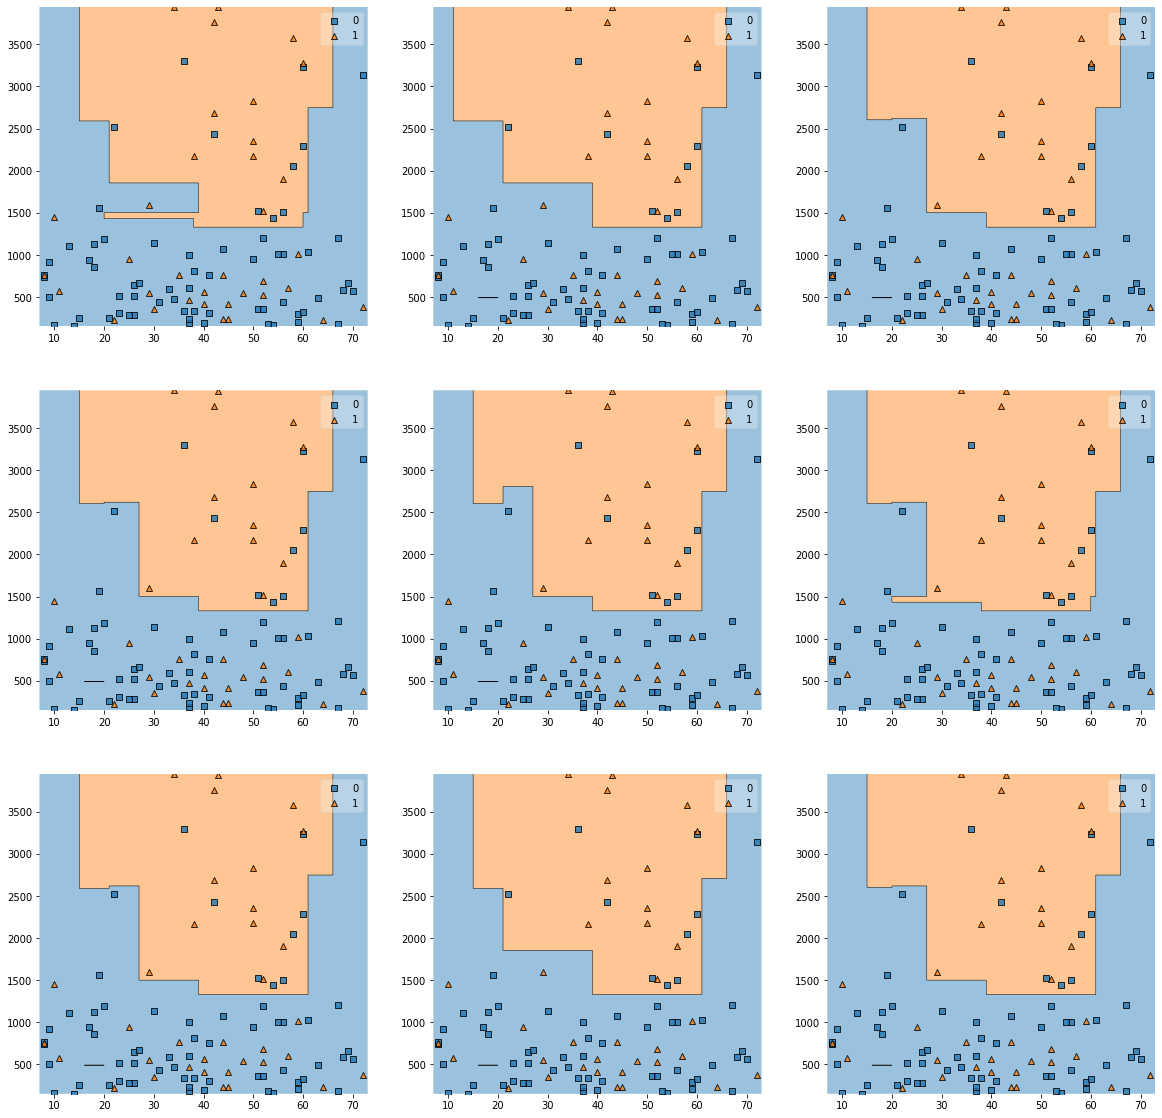

In [ ]:
# замените X_train_example на вашу переменную

fig, ax = plt.subplots(3, 3, figsize=(20, 20))

for row in range(3):
    for col in range(3):
        inds = np.random.choice(X_train_example.index, size=X_train_example.shape[0] - 1000, replace=False) # нагляднее брать не на 1к, а на 5к меньше объектов, а то почти не изменяется разделяющая поверхность

        tree_exp = DecisionTreeClassifier(max_depth=5, random_state=42)
        tree_exp.fit(X_train_example.loc[inds, :], y_train[inds])

        plot_decision_regions(clf=tree_exp, X=np.array(X_train_example.iloc[:100, :]), y=np.array(y_train[:100]), ax=ax[row][col])

**Смотрите как двигается гранится, а ведь мы убирали из трейна (а в нем ~80к наблюдений) всего по тысяче случайных объектов!**

Помимо своей неусточивости деревья решений "славны" ещё и склонностью к переобучению. Посмотрим, можно ли увидеть это свойство на имеющихся у нас данных. Для этого будем обучать алгоритм DT на всем трейне с разной глубиной дерева и считать accuracy для теста

In [ ]:
# замените X_train_example на вашу переменную (ohe-encoded)

%%time
depths = [2, 3, 5, 10, 15, 20, 25, 32, 50, 64, 75, 100]

accuracies_train = []
accuracies_test = []
for max_depth in depths:
    DT = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    DT.fit(X_train_enc, y_train)
    y_predicted_train = DT.predict(X_train_enc)
    y_predicted_val = DT.predict(X_val_enc)
    accuracies_train.append(accuracy_score(y_train, y_predicted_train))
    accuracies_test.append(accuracy_score(y_val, y_predicted_val))

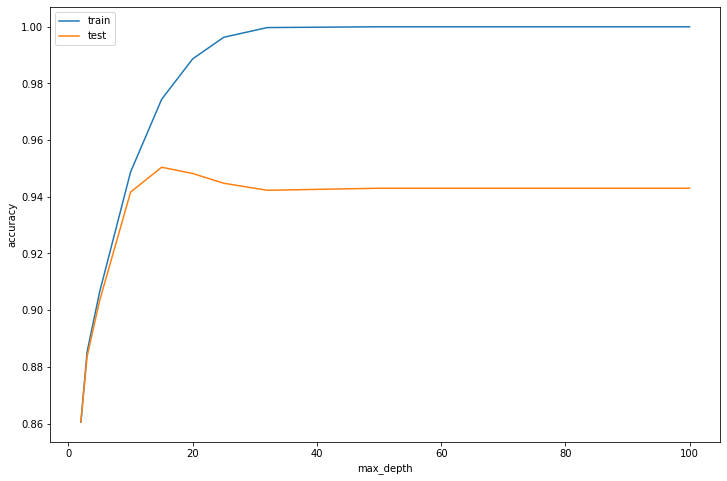

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(depths, accuracies_train, depths, accuracies_test)
plt.legend(['train', 'test'])
plt.ylabel('accuracy')
plt.xlabel('max_depth')
plt.show()

Нам повезло выйти на ассимптоту на тесте. Однако так бывает далеко не всегда. Так что подбирать гипрепараметры для деревьев решений стоит осторожно

## **Возвращение к задаче**

### **Задание 20. (0.4 балла)**

- На кроссвалидации подберите оптимальные гиперпараметры для дерева решений *(по данным со всеми признаками -- не на модельном примере из теоретической вставки)*.
- Удалось ли улучшить качество предсказаний подбором гиперпараметров?

In [48]:
param_grid = {
    'max_depth': [3, 7, 12, 18],
    'min_samples_split': [2, 7, 10, 15],
    'min_samples_leaf': [2, 7, 10],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_ohe, y_train_ohe)

print(f"Best params: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

y_pred = grid_search.best_estimator_.predict(X_val_ohe)

val_acc = accuracy_score(y_val_ohe, y_pred)
print(f"accuracy score: {accuracy_score(y_val_ohe, y_pred)}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best params: {'max_depth': 18, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 15}
Best score: 0.9463548098781555
accuracy score: 0.9459477124183007


Удалось улучшить результат accuracy 0.91 -> 0.95

### **Задание 21. (0.1 балла)**

- Сохраните лучшее дерево в pickle

*Мы просим это сделать, чтобы вы в случае чего не тратили время на переобучение, а могли банально подгрузить из файла*

In [49]:
with open('DT.pkl', 'wb') as f:
    pickle.dump(grid_search.best_estimator_, f)

# **Часть 3. Random Forest (4.25 балла)**

### **Задание 22. (0.05 балла)**
- Обучите случайный лес с параметрами по умолчанию

In [50]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train_ohe, y_train_ohe)
y_pred = random_forest.predict(X_val_ohe)
print(f"accuracy score: {accuracy_score(y_val_ohe, y_pred)}")

accuracy score: 0.9605228758169935


### **Задание 23. (0.15 балла)**
- Выведите калибровочную кривую для полученного ансамбля

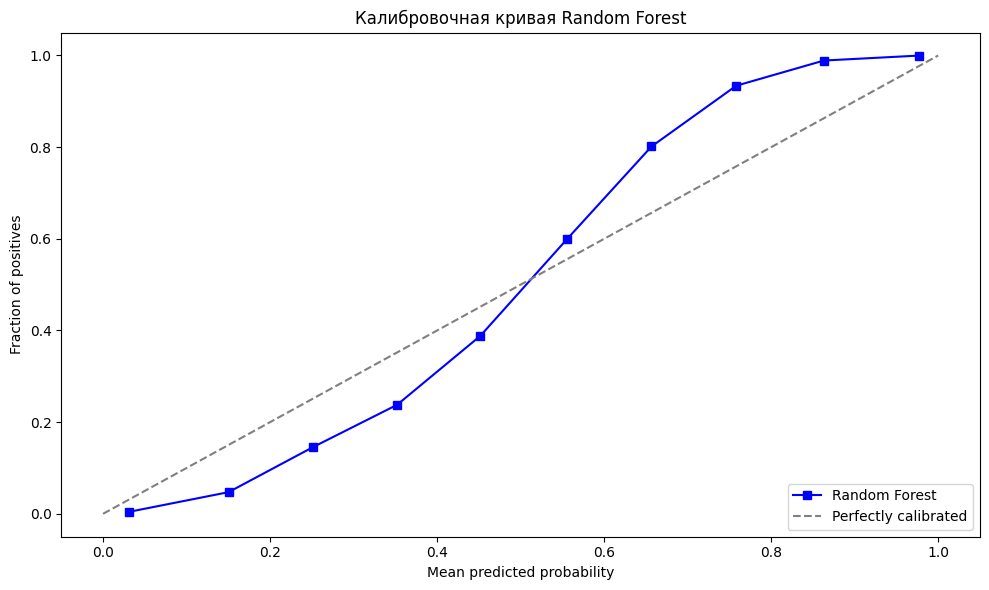

In [51]:
y_pred_proba = random_forest.predict_proba(X_val_ohe)[:, 1]
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val_ohe, y_pred_proba, n_bins=10, strategy='uniform'
)

plt.figure(figsize=(10, 6))
plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    's-',
    label='Random Forest',
    color='blue'
)
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Калибровочная кривая Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Похоже, мы немного недооцениваем высокие вероятности

<img src='https://habrastorage.org/r/w1560/getpro/habr/upload_files/510/4e0/63b/5104e063b62bd0ac6b87da44a3034aa5.png'>

Изображение взято из статьи ["predict_proba в Python не прогнозирует вероятности (и как с этим бороться)"](https://habr.com/ru/company/otus/blog/573924/) с Хабра

### **Задание 24. (0.4 балла)**

- Вспомните (или выведите), корректно ли деревья предсказывают вероятности?

Нет, деревья некорректно предсказывают вероятности

### **Задание 25. (0.15 балла)**
- Обучите логистическую регрессию так, чтобы она сошлась
- Отобразите её калибровочную кривую

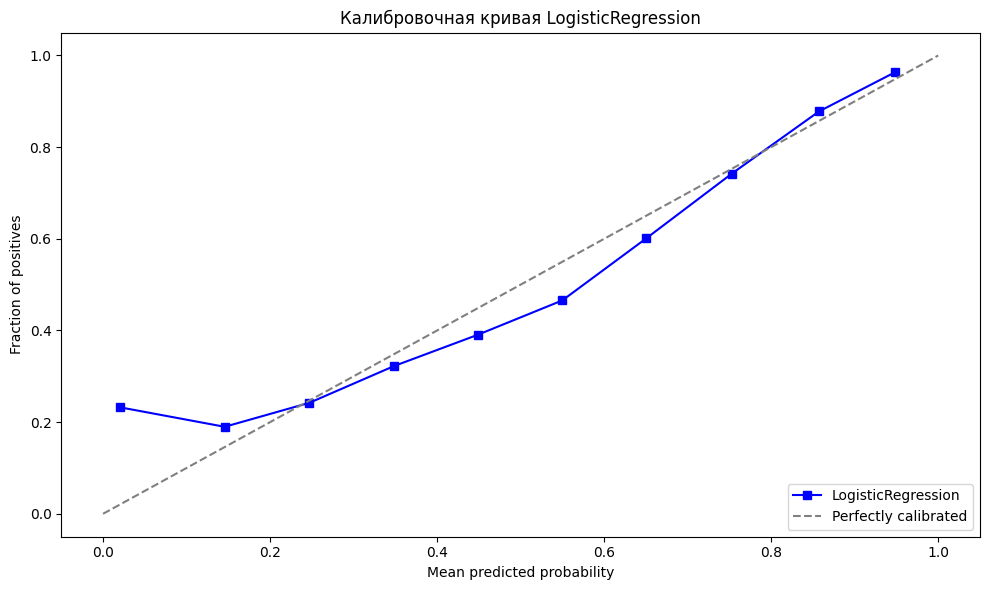

In [62]:
lr = LogisticRegression(random_state=42, n_jobs=-1)

lr.fit(X_train_ohe, y_train_ohe)
y_pred_proba_lr = lr.predict_proba(X_val_ohe)[:, 1]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val_ohe, y_pred_proba_lr, n_bins=10, strategy='uniform'
)

plt.figure(figsize=(10, 6))
plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    's-',
    label='LogisticRegression',
    color='blue'
)
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Калибровочная кривая LogisticRegression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Мы немного переоцениваем предсказанные низкие вероятности

### **Задание 26. (0.2 балла)**
- Покажите, почему считается, что логистическая регрессия корректно предсказывает вероятности?

Логистическая регрессия предсказывает вероятности корректно благодаря функции потерь, которая штрафует за уверенные неправильные предсказания.

### **Задание 27. (0.35 балла)**

Предлагаем вам попробовать откалибровать вероятности обученного случайного леса!

- Откалибруйте вероятности, при помощи логистической и изотонической регрессий.
- Интерпретируйте полученные результаты

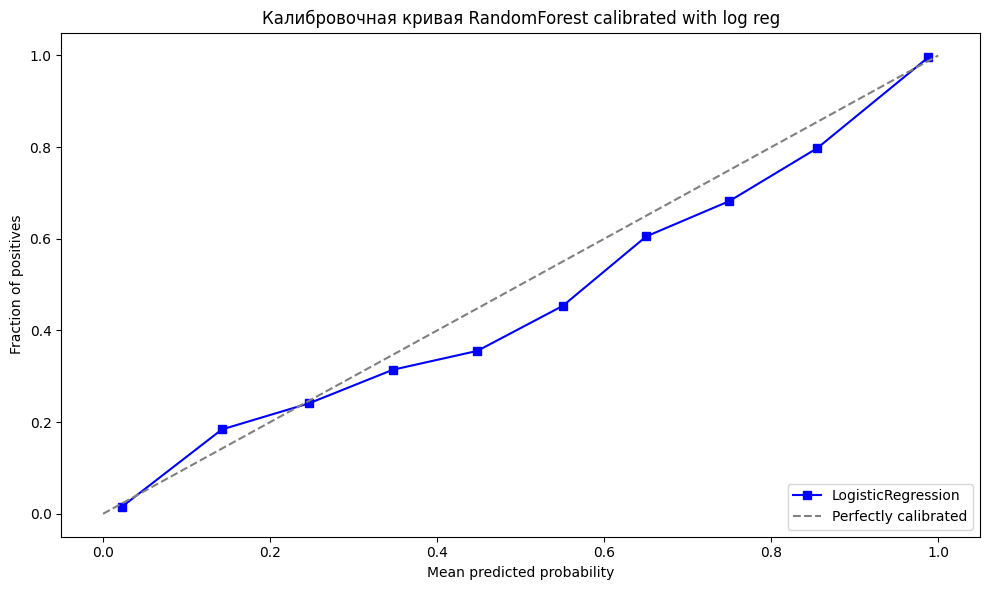

In [55]:
random_forest_calibrated_sig = CalibratedClassifierCV(
    random_forest,
    method='sigmoid',
    cv=5
)
random_forest_calibrated_sig.fit(X_train_ohe, y_train_ohe)

y_pred_proba_sig = random_forest_calibrated_sig.predict_proba(X_val_ohe)[:, 1]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val_ohe, y_pred_proba_sig, n_bins=10, strategy='uniform'
)

plt.figure(figsize=(10, 6))
plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    's-',
    label='LogisticRegression',
    color='blue'
)
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Калибровочная кривая RandomForest calibrated with log reg')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

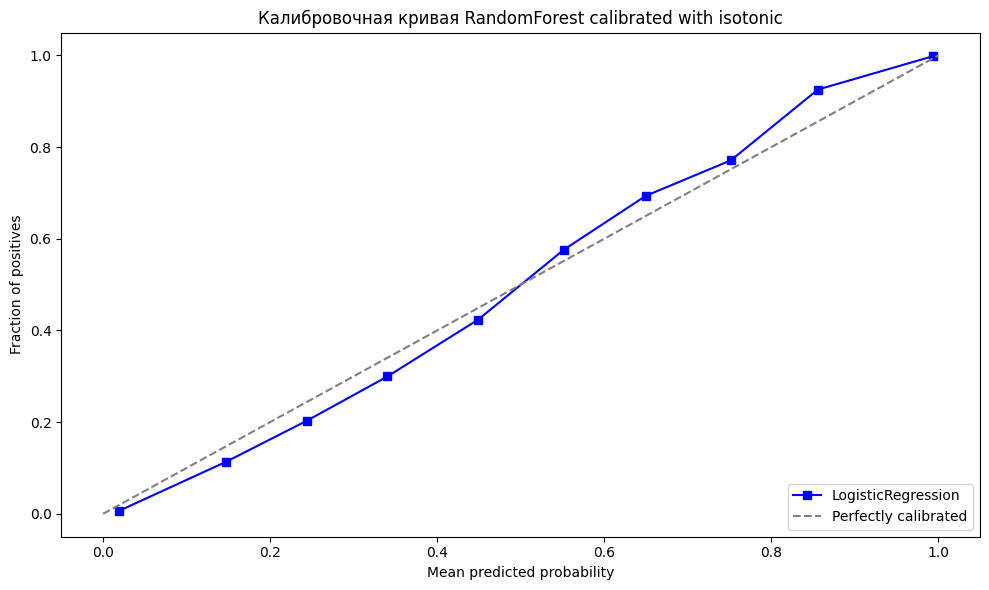

In [56]:
random_forest_calibrated_iso = CalibratedClassifierCV(
    random_forest,
    method='isotonic',
    cv=5
)
random_forest_calibrated_iso.fit(X_train_ohe, y_train_ohe)

y_pred_proba_iso = random_forest_calibrated_iso.predict_proba(X_val_ohe)[:, 1]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val_ohe, y_pred_proba_iso, n_bins=10, strategy='uniform'
)

plt.figure(figsize=(10, 6))
plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    's-',
    label='LogisticRegression',
    color='blue'
)
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Калибровочная кривая RandomForest calibrated with isotonic')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Изотоническая регрессия дала лучшую калибровку, так как она более гибко подстраивается под данные.

### **Задание 28. (0.2 балла)**
- Опишите другие возвожные подходы к калибровке вероятностей (со ссылками на источники)

- Beta calibration - https://betacal.github.io/
- Temperature scaling - https://docs.aws.amazon.com/prescriptive-guidance/latest/ml-quantifying-uncertainty/temp-scaling.html

### **Задание 29. (0.5 баллa)**

Проанализируйте лес.
- Посчитайте разброс и смещение полученного случайного леса (до калибровки).
- Оличаются ли они от полученных для дерева решений?
- Соответствуют ли полученные на реальных данных отличия (//совпадения) от тех, что должны быть в теории? По каким причинам?

In [59]:
error_dt, bias_dt, var_dt = bias_variance_decomp(
    random_forest,
    X_train_ohe.values, y_train_ohe.values,
    X_val_ohe.values, y_val_ohe.values,
    loss='0-1_loss',
    num_rounds=50
)

print(f"Error: {error_dt}")
print(f"Bias:  {bias_dt}")
print(f"Variance: {var_dt}")

Error: 0.0409843137254902
Bias:  0.0392156862745098
Variance: 0.009528104575163399


Для Decision Tree:
- `Bias` = 0.052
- `Variance` = 0.07
- `Error` = 0.088

Для Random Forest:
- `Bias` = 0.039
- `Variance` = 0.01
- `Error` = 0.041

Все показатели снизились. Снижение `Variance` соответствует теории, снижение `Bias` - нет. Однако снижение `Bias` не такое коорднальное и можно сослаться на погрешность + расчет происходил на `num_rounds=50` в связи с продолжительностью этой процедуры.

### **Задание 30. (0.5 баллa)**

- Вычислите разложение ошибки для логистической регрессии (ванильной, которую вы обучили для решения задачи в задании 25, а не той, что использовали для калибровки)
- Сравните полученные результаты с предыдущими.
- Объясните природу этих результатов

In [64]:
error_dt, bias_dt, var_dt = bias_variance_decomp(
    lr,
    X_train_ohe.values, y_train_ohe.values,
    X_val_ohe.values, y_val_ohe.values,
    loss='0-1_loss'
)

print(f"Error: {error_dt}")
print(f"Bias:  {bias_dt}")
print(f"Variance: {var_dt}")

Error: 0.21400261437908497
Bias:  0.21173202614379086
Variance: 0.025058169934640523


Значения метрик получились хуже, чем для дерева решений и для рандомного леса. Высокий bias говорит о том, что модель недообучена и не может отследить линейные зависимости в данных. Variance же получился на уровне деревьев, можно сказать, что модель стабильна.

### **Задание 31. (0.8 баллa)**

- Попробуйте подобрать оптимальные гиперпараметры леса, используя [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

**Важно:**  

Хотя бы один из гиперпараметров перебирайте из распределения (например, `uniform` из `scipy.stats`)

In [71]:
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 25),
    'max_features': ['sqrt', 'log2'],
    'ccp_alpha': uniform(0, 0.05)
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_ohe, y_train_ohe)
print(f"best params: {random_search.best_params_}")
print(f"best accuracy: {random_search.best_score_:.4f}")

y_pred = random_search.predict(X_val_ohe)
print(f"accuracy on validation: {accuracy_score(y_val_ohe, y_pred)}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
best params: {'ccp_alpha': np.float64(0.0017194260557609198), 'max_depth': 16, 'max_features': 'sqrt', 'n_estimators': 99}
best accuracy: 0.9240
accuracy on validation: 0.9247058823529412


## **Случайный лес. Вставка теории**

На модельном примере посмотрим, склонен ли случайный лес к переобучению с ростом числа деревьев в композиции.

Возьмем 4 полезных признака из одного из предыдщущих заданий, напоминающих теорию

In [ ]:
# замените X_train_enc на ваш трейн

cols_for_RF = ['age', 'Flight Distance', 'Online boarding', 'Inflight wifi service']
X_train_RF = X_train_enc[cols_for_RF]
# а тест нам не понадобится, ведь можно получить OOB-estimate ошибки

clf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=42)
errors = []

for n_estimators in range(1, 251, 5):
    clf.set_params(n_estimators=n_estimators)
    clf.fit(X_train_RF, y_train)

    errors.append(1 - clf.oob_score_)

Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.


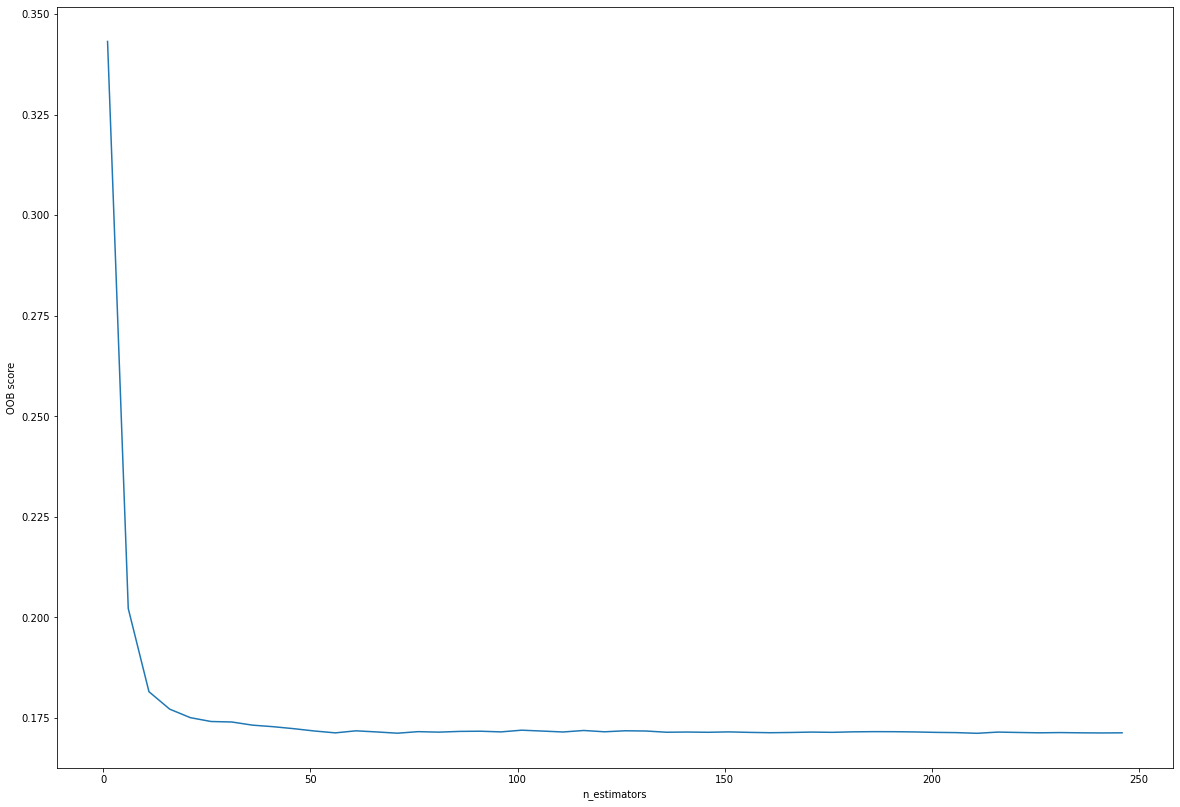

In [ ]:
plt.figure(figsize=(20, 14))
plt.plot(range(1, 251, 5), errors)

plt.xlabel('n_estimators')
plt.ylabel('OOB score')
plt.show()

**Дисклеймер**: отсутствие переобучения с ростом числа деревьев вовсе не означает, что сама модель случайного леса не может быть переобучена. Базовые деревья такой композиции могут переобучаться. Значит, и вся композиция вполне способна оказаться переобученной

## **Возвращение к задаче**

### **Задание 32. (0.6 баллa)**

- Отобразите`feature_importances_` вашего лучшего случайного леса
- Сравните важности признаков для дерева решений и для случайного леса. Постройте диаграмму


Подобрать параметры, которые бы давали точность лучше, чем на дефолтном случайном лесе не удалось, поэтому дальше будем работать с ним.

In [72]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train_ohe, y_train_ohe)

RandomForestClassifier()

In [75]:
rf_importance = random_forest.feature_importances_
rf_imp_df = pd.DataFrame({
    'feature': X_train_ohe.columns,
    'importance': rf_importance
}).sort_values('importance', ascending=False)

dt_importance = grid_search.best_estimator_.feature_importances_
dt_imp_df = pd.DataFrame({
    'feature': X_train_ohe.columns,
    'importance': dt_importance
}).sort_values('importance', ascending=False)

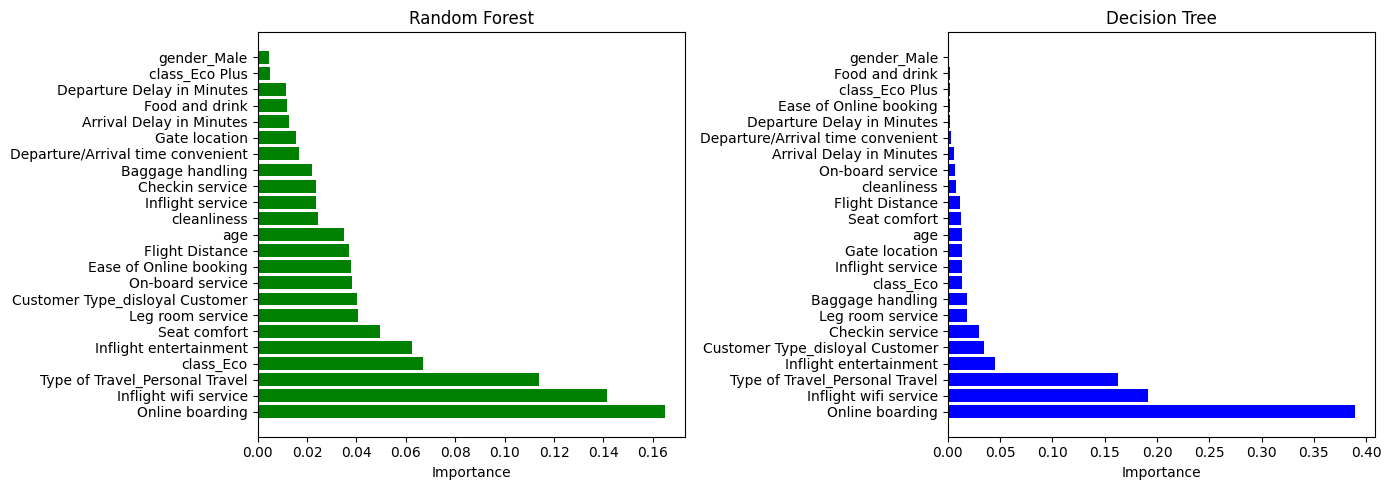

In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(rf_imp_df['feature'], rf_imp_df['importance'], color='green')
ax1.set_title('Random Forest')
ax1.set_xlabel('Importance')

ax2.barh(dt_imp_df['feature'], dt_imp_df['importance'], color='blue')
ax2.set_title('Decision Tree')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()

Как видим, разница между наиболее и наименее важным параметров в случайном лесу намного меньше, чем в DecisionTree. Плюс лидеры по важности уже не так явно выбиваются. В Decision Tree только 3 параметра составляют основную важность.

### **Задание 33. (0.1 баллa)**

- Случайный лес, дающий лучший скор, [сохраните в pickle](https://scikit-learn.ru/stable/model_persistence.html)

In [78]:
with open('RF.pkl', 'wb') as f:
    pickle.dump(random_forest, f)

### **Задание 34. (0.25 балла)**
- Интерпретируйте важности признаков с помощью SHAP.
- Опишите полученый график

**Важно:** Для подсчета используйте 1000 случайных объектов, иначе не дождетесь за приемлемое время

**Вам может помочь:** [Статья "Интерпретация моделей и диагностика сдвига данных: LIME, SHAP и Shapley Flow"](https://habr.com/ru/company/ods/blog/599573/) из блога ods.ai на Хабре

/tmp/ipykernel_515/2855775936.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_sample, feature_names=X_sample.columns, show=False)
/tmp/ipykernel_515/2855775936.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 0], X_sample, feature_names=X_sample.columns, show=False)


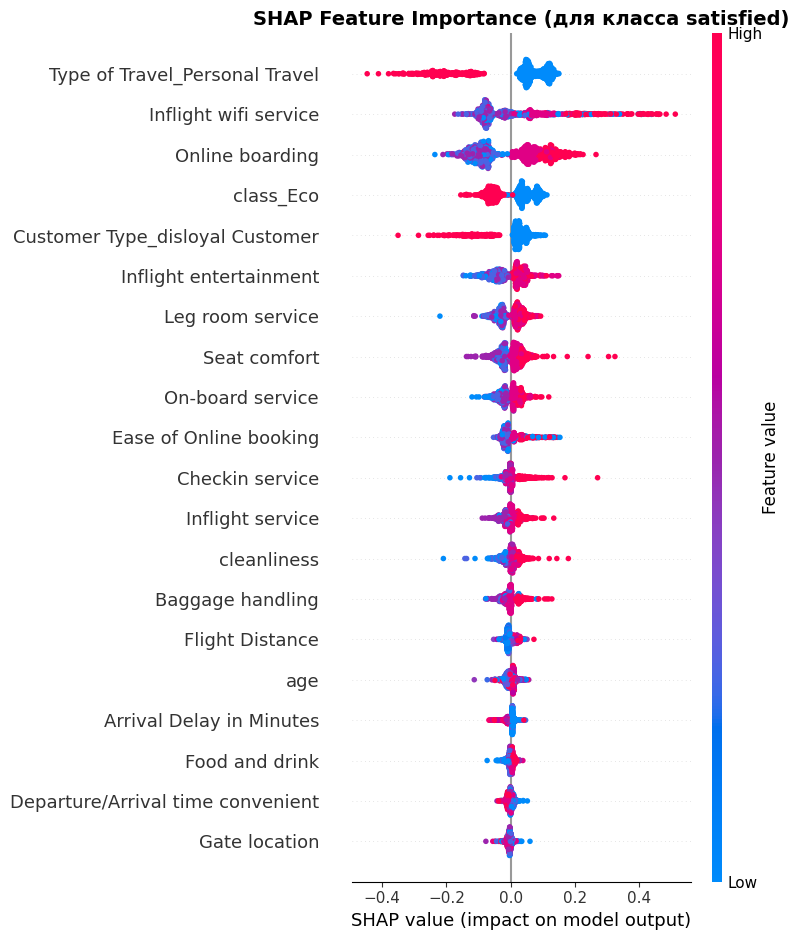

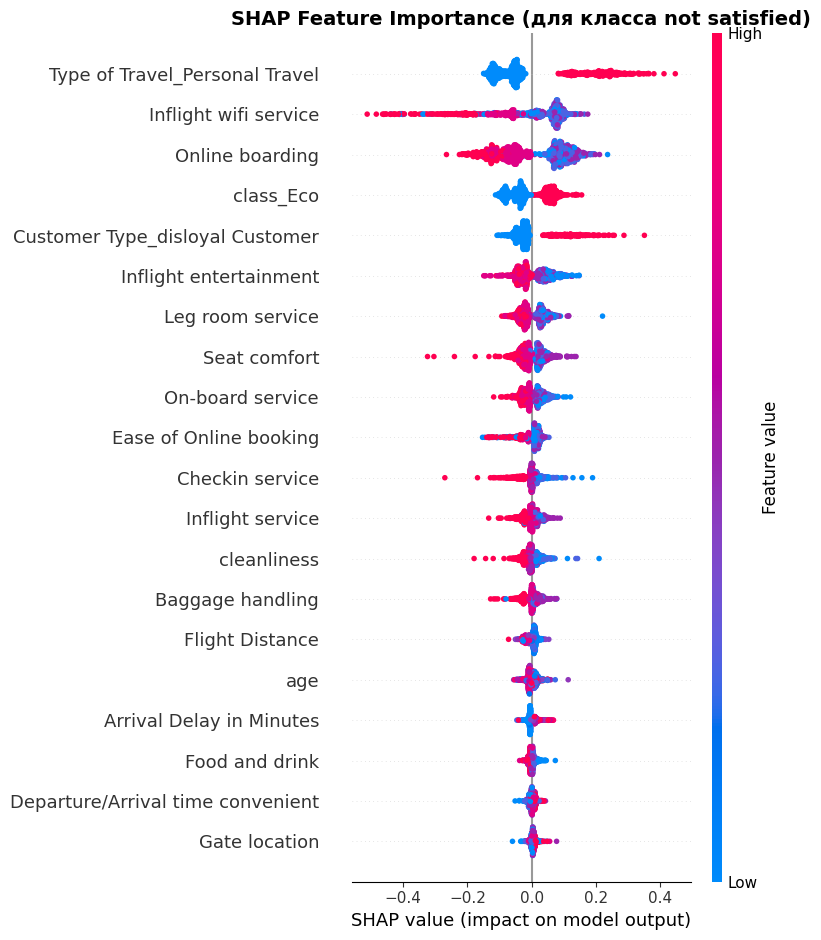

In [90]:
X_sample = X_train_ohe.sample(n=1000, random_state=42)
y_sample = y_train_ohe.loc[X_sample.index]

explainer = shap.TreeExplainer(random_forest)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[:, :, 1], X_sample, feature_names=X_sample.columns, show=False)
plt.title('SHAP Feature Importance (для класса satisfied)', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[:, :, 0], X_sample, feature_names=X_sample.columns, show=False)
plt.title('SHAP Feature Importance (для класса not satisfied)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Как видим здесь, данные, полученные с помощью SHAP примерно сходятся с важностью признаков, полученные из модели.

### **Бонус (0.1 балл)**

- Изучите документацию библиотеки SHAP. Что ещё полезного в ней имеется?

`Ваш ответ здесь`

### **Бонус (0.5 балла)**

- Интерпретируйте важности признаков для одного прогноза с помощью LIME;
- Опишите полученный график для выбранного наблюдения

In [95]:
sample_idx = 1234
instance = X_val_ohe.iloc[sample_idx].values
true_label = y_val_ohe.iloc[sample_idx]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_ohe.values,
    feature_names=X_train_ohe.columns.tolist(),
    class_names=['neutral/dissatisfied', 'satisfied'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=random_forest.predict_proba
)
explanation.show_in_notebook(show_table=True, show_all=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Как видим, вероятность того, что клиент будет dissatisfied на данном семлпе = 96%.
- Бизнес рейс повышает вероятность удовлетворенности +0.3
- Клиент нелояльный, что повышает вероятность неудовлетворенности +0.15
- Плохой wifi, что повышает вероятность неудовлетворенности +0.11
- Низкая оценка онлайн-посадки, что повышает вероятность неудовлетворенности +0.08

# Обратная связь

Расскажите, как вам это домашнее задание. Было ли оно полезным? Научились ли вы чему то? Насколько сложным по 10-балльной шкале оно вам показалось? Сколько времени у вас ушло на его выполнение? Что следовало ещё в него включить? Было ли что-то лишнее?